# Modelo de Riesgo a 14 Días — ChicharritAI

Modelo operacional que predice el riesgo de que una localidad supere el umbral de captura de *Dalbulus maidis* en los **próximos 14 días**, usando:

1. **Historial local de trampas** — capturas recientes, tendencia, máximo acumulado
2. **Propagación espacial** — capturas en localidades cercanas (50/100/200 km)
3. **Clima reciente y actual** — temperatura, humedad, precipitación, viento (Open-Meteo)
4. **Contexto estacional** — posición en la temporada, ENSO, severidad del invierno
5. **Geografía** — latitud, distancia a zona endémica

**Unidad de predicción**: (localidad, período de lectura) → ¿capturas ≥ 5 en los próximos 14 días?

**Split temporal**: Train en temporada 2024-2025, Test en temporada 2025-2026.

In [1]:
import json
import re
import warnings
from datetime import datetime, timedelta
from math import radians, sin, cos, sqrt, atan2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, precision_recall_curve, average_precision_score, f1_score,
)
from sklearn.inspection import permutation_importance
import shap

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", font_scale=1.1)
TARGET_COLORS = {0: "#2ecc71", 1: "#e74c3c"}

# Config
CAPTURE_THRESHOLD = 5  # ≥5 adultos/trampa = outbreak
CSVS_DIR = "csvs"
N_REPORTS = 38
ENDEMIC_LAT, ENDEMIC_LON = -26.8, -65.2

REPORT_SEASON_MAP = {i: "2024-2025" for i in range(1, 22)}
REPORT_SEASON_MAP.update({i: "2025-2026" for i in range(22, 39)})

NON_READING_COLS = {"zona", "región", "region", "provincia", "provincia/pais",
                    "localidad", "latitud", "longitud"}

LOCALIDAD_REPLACEMENTS = {
    "gral.": "general", "gral ": "general ",
    "nstra": "nuestra",
}

print("Setup completo.")

/Users/alexanderbodner/Documents/hackitba2026/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup completo.


---
## ¿Por dónde empezar?

### Camino A — Generar el dataset desde cero (primera vez)
Ejecutar en orden las secciones **1 → 2** (celdas de carga de CSVs + construcción de features). Al final de la Sección 2 hay una celda que guarda `output/dataset_14d.csv`. Luego continuar con la Sección 3 en adelante.

> ⏱ Tiempo estimado: ~10–20 min (fetching de clima vía API para localidades sin cache).

### Camino B — Cargar el dataset ya generado ✅ (recomendado si `output/dataset_14d.csv` existe)
1. Ejecutar la celda **1 — Setup e imports** (celda de configuración inicial).
2. Saltar directamente a la sección **"Cargar dataset desde CSV"** y ejecutar esa celda.
3. Continuar con la Sección 3 (EDA), 4 (XGBoost), 12 (MLP), etc.

---

## 1. Carga de datos crudos — Lecturas con fechas

Cargamos todos los informes (38 CSVs) en formato long, conservando las **fechas exactas** de cada lectura para construir la serie temporal por localidad.

In [2]:
# --- Funciones de carga ---

def parse_date_range(col_name):
    """Parsea rango de fechas de nombre de columna."""
    match = re.search(r"(\d{2}_\d{2}_\d{2})_al_(\d{2}_\d{2}_\d{2})", col_name)
    if not match:
        raise ValueError(f"No se pudo parsear fecha: {col_name}")
    start = datetime.strptime(match.group(1), "%d_%m_%y")
    end = datetime.strptime(match.group(2), "%d_%m_%y")
    return start, end


def normalize_localidad(name):
    s = name.strip().lower()
    for abbr, full in LOCALIDAD_REPLACEMENTS.items():
        s = s.replace(abbr, full)
    s = re.sub(r"\s+\d+$", "", s)
    s = re.sub(r"\s*\(.*?\)\s*$", "", s)
    s = re.sub(r"\s+t\d+$", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def parse_capturas(val):
    if pd.isna(val):
        return float("nan")
    s = str(val).strip().lower()
    if s in ("", "sin datos", "trampa perdida"):
        return float("nan")
    try:
        return float(s)
    except ValueError:
        return float("nan")


def load_all_reports_long():
    """Carga todos los CSVs → formato long con fechas."""
    all_rows = []
    for report_num in range(1, N_REPORTS + 1):
        path = f"{CSVS_DIR}/{report_num}.csv"
        df = pd.read_csv(path, dtype=str, on_bad_lines="warn")
        df.columns = [c.strip() for c in df.columns]
        cols_lower = {c: c.lower() for c in df.columns}

        fixed_cols, reading_cols = [], []
        for col in df.columns:
            if cols_lower[col] in NON_READING_COLS:
                fixed_cols.append(col)
            else:
                reading_cols.append(col)

        rename_fixed = {}
        for c in fixed_cols:
            low = c.lower()
            if low in ("zona", "región", "region"): rename_fixed[c] = "region"
            elif low in ("provincia", "provincia/pais"): rename_fixed[c] = "provincia"
            elif low == "localidad": rename_fixed[c] = "localidad"
        df.rename(columns=rename_fixed, inplace=True)

        id_cols = [c for c in ["region", "provincia", "localidad"] if c in df.columns]

        for col in reading_cols:
            if col.lower() in ("latitud", "longitud"):
                continue
            try:
                fecha_inicio, fecha_fin = parse_date_range(col)
            except ValueError:
                continue

            subset = df[id_cols + [col]].copy()
            subset = subset.rename(columns={col: "capturas_raw"})
            subset["informe"] = report_num
            subset["fecha_inicio"] = fecha_inicio
            subset["fecha_fin"] = fecha_fin
            subset["temporada"] = REPORT_SEASON_MAP[report_num]
            all_rows.append(subset)

    result = pd.concat(all_rows, ignore_index=True)
    result = result.dropna(subset=["localidad"])
    result = result[result["localidad"].str.strip() != ""]
    result["localidad"] = result["localidad"].apply(normalize_localidad)
    result["provincia"] = result["provincia"].fillna("").str.strip().str.title()
    result["region"] = result["region"].fillna("").str.strip().str.upper()
    result["capturas"] = result["capturas_raw"].apply(parse_capturas)
    result["fecha_mid"] = result["fecha_inicio"] + (result["fecha_fin"] - result["fecha_inicio"]) / 2

    return result


readings = load_all_reports_long()
print(f"Total lecturas crudas: {len(readings)}")
print(f"Localidades únicas: {readings['localidad'].nunique()}")
print(f"Rango de fechas: {readings['fecha_inicio'].min()} → {readings['fecha_fin'].max()}")
print(f"Lecturas válidas (no NaN): {readings['capturas'].notna().sum()}")
print(f"\nPor temporada:")
print(readings.groupby("temporada").agg(
    n_lecturas=("capturas", "count"),
    n_validas=("capturas", lambda x: x.notna().sum()),
    localidades=("localidad", "nunique"),
))

/var/folders/k5/m3vphss513b3ggz7lzrn75440000gn/T/ipykernel_61343/509545831.py:41: ParserWarning: Skipping line 458: expected 6 fields, saw 7
Skipping line 459: expected 6 fields, saw 7
Skipping line 460: expected 6 fields, saw 7
Skipping line 461: expected 6 fields, saw 7
Skipping line 462: expected 6 fields, saw 7
Skipping line 463: expected 6 fields, saw 7
Skipping line 464: expected 6 fields, saw 7
Skipping line 465: expected 6 fields, saw 7

  df = pd.read_csv(path, dtype=str, on_bad_lines="warn")


Total lecturas crudas: 47066
Localidades únicas: 596
Rango de fechas: 2024-07-15 00:00:00 → 2026-03-16 00:00:00
Lecturas válidas (no NaN): 41752

Por temporada:
           n_lecturas  n_validas  localidades
temporada                                    
2024-2025       23751      23751          511
2025-2026       18001      18001          495


In [3]:
# Cargar coordenadas geocodificadas
with open("cache/geocoding.json") as f:
    coords_cache = json.load(f)

def get_coords(row):
    key = f"{row['localidad']}__{row['provincia']}"
    c = coords_cache.get(key)
    if c:
        return pd.Series({"lat": c["lat"], "lon": c["lon"]})
    return pd.Series({"lat": np.nan, "lon": np.nan})

coords = readings[["localidad", "provincia"]].drop_duplicates().apply(get_coords, axis=1)
coords["localidad"] = readings[["localidad", "provincia"]].drop_duplicates()["localidad"].values
coords["provincia"] = readings[["localidad", "provincia"]].drop_duplicates()["provincia"].values

readings = readings.merge(coords, on=["localidad", "provincia"], how="left")

# Filtrar lecturas sin coordenadas o capturas
readings_valid = readings[readings["lat"].notna() & readings["capturas"].notna()].copy()
print(f"Lecturas con coordenadas y capturas válidas: {len(readings_valid)}")
print(f"Localidades con datos: {readings_valid['localidad'].nunique()}")

Lecturas con coordenadas y capturas válidas: 39807
Localidades con datos: 528


## 2. Construcción del dataset temporal

Para cada localidad, ordenamos las lecturas cronológicamente y armamos pares **(lectura actual → ¿outbreak en la siguiente lectura?)**.

### Features por categoría:
- **Historial local**: capturas actuales, previas, tendencia, acumulado
- **Propagación espacial**: capturas en vecinos cercanos
- **Clima reciente**: condiciones meteorológicas del período actual (14 días)
- **Temporal/estacional**: posición en la temporada, mes
- **Geográfico**: latitud, distancia a zona endémica

In [11]:
# --- Utilidades ---

def haversine(lat1, lon1, lat2, lon2):
    """Distancia en km entre dos puntos."""
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))


def haversine_vectorized(lat1, lon1, lat2_arr, lon2_arr):
    """Distancia vectorizada de un punto a muchos."""
    R = 6371
    lat1_r, lon1_r = np.radians(lat1), np.radians(lon1)
    lat2_r, lon2_r = np.radians(lat2_arr), np.radians(lon2_arr)
    dlat = lat2_r - lat1_r
    dlon = lon2_r - lon1_r
    a = np.sin(dlat/2)**2 + np.cos(lat1_r) * np.cos(lat2_r) * np.sin(dlon/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))


print("Funciones de distancia listas.")

Funciones de distancia listas.


In [5]:
# 2.1 Ordenar lecturas por localidad y fecha, construir pares (t → t+1)

# Agrupar por localidad+provincia+temporada, agregar por período (para trampas duplicadas)
readings_agg = (
    readings_valid
    .groupby(["localidad", "provincia", "region", "temporada", "lat", "lon",
              "fecha_inicio", "fecha_fin", "fecha_mid"])
    .agg(
        capturas_max=("capturas", "max"),
        capturas_mean=("capturas", "mean"),
        n_trampas=("capturas", "count"),
    )
    .reset_index()
    .sort_values(["localidad", "provincia", "temporada", "fecha_inicio"])
)

print(f"Lecturas agregadas (por localidad + período): {len(readings_agg)}")
print(f"\nEjemplo (acequiones):")
display(readings_agg[readings_agg["localidad"] == "acequiones"][["localidad", "temporada", "fecha_inicio", "fecha_fin", "capturas_max", "capturas_mean"]].head(10))

Lecturas agregadas (por localidad + período): 15394

Ejemplo (acequiones):


,localidad,temporada,fecha_inicio,fecha_fin,capturas_max,capturas_mean
177,acequiones,2024-2025,2024-07-15,2024-08-01,10.0,10.0
178,acequiones,2024-2025,2024-07-15,2024-08-02,10.0,10.0
179,acequiones,2024-2025,2024-08-01,2024-08-17,5.0,5.0
180,acequiones,2024-2025,2024-08-02,2024-08-17,5.0,5.0
181,acequiones,2024-2025,2024-08-18,2024-09-03,0.0,0.0
182,acequiones,2024-2025,2024-09-04,2024-09-18,0.0,0.0
183,acequiones,2024-2025,2024-09-19,2024-10-03,0.0,0.0
184,acequiones,2024-2025,2024-09-19,2024-10-04,0.0,0.0
185,acequiones,2024-2025,2024-10-04,2024-10-21,0.0,0.0
186,acequiones,2024-2025,2024-10-22,2024-11-08,0.0,0.0


In [14]:
# 2.2 Para cada lectura, calcular el target: ¿la SIGUIENTE lectura tiene capturas >= THRESHOLD?

pairs = []
loc_groups = readings_agg.groupby(["localidad", "provincia", "temporada"])

for (loc, prov, temp), group in tqdm(loc_groups, desc="Construyendo pares", unit="localidad"):
    group = group.sort_values("fecha_inicio").reset_index(drop=True)
    if len(group) < 2:
        continue

    for i in range(len(group) - 1):
        current = group.iloc[i]
        next_reading = group.iloc[i + 1]

        # Target: outbreak en la siguiente lectura
        target = int(next_reading["capturas_max"] >= CAPTURE_THRESHOLD)

        # Historial acumulado hasta el momento actual
        history = group.iloc[:i+1]

        pairs.append({
            "localidad": loc,
            "provincia": prov,
            "region": current["region"],
            "temporada": temp,
            "lat": current["lat"],
            "lon": current["lon"],
            "fecha_inicio": current["fecha_inicio"],
            "fecha_fin": current["fecha_fin"],
            "fecha_mid": current["fecha_mid"],
            "next_fecha_inicio": next_reading["fecha_inicio"],
            "next_fecha_fin": next_reading["fecha_fin"],

            # --- FEATURES: Historial local ---
            "capturas_actual": current["capturas_max"],
            "capturas_mean_actual": current["capturas_mean"],
            "capturas_prev": group.iloc[i-1]["capturas_max"] if i > 0 else 0.0,
            "capturas_max_acum": history["capturas_max"].max(),
            "capturas_mean_acum": history["capturas_max"].mean(),
            "capturas_trend": current["capturas_max"] - group.iloc[i-1]["capturas_max"] if i > 0 else 0.0,
            "capturas_log1p": np.log1p(current["capturas_max"]),
            "n_readings_season": i + 1,
            "n_detecciones_acum": int((history["capturas_max"] > 0).sum()),
            "ratio_detecciones": (history["capturas_max"] > 0).sum() / len(history),
            "is_currently_outbreak": int(current["capturas_max"] >= CAPTURE_THRESHOLD),
            "n_trampas": current["n_trampas"],

            # Target
            "target": target,
            "next_capturas": next_reading["capturas_max"],
        })

df_pairs = pd.DataFrame(pairs)

print(f"Pares (lectura → siguiente): {len(df_pairs)}")
print(f"Target=1 (outbreak en siguiente): {df_pairs['target'].sum()} ({df_pairs['target'].mean():.1%})")
print(f"Target=0 (safe en siguiente):    {(df_pairs['target']==0).sum()} ({(df_pairs['target']==0).mean():.1%})")
print(f"\nPor temporada:")
print(df_pairs.groupby("temporada")["target"].agg(["count", "sum", "mean"]).round(3))
print(f"\nNaN check historial: capturas_prev={df_pairs['capturas_prev'].isna().sum()}, capturas_trend={df_pairs['capturas_trend'].isna().sum()}")

Pares (lectura → siguiente): 14402
Target=1 (outbreak en siguiente): 3621 (25.1%)
Target=0 (safe en siguiente):    10781 (74.9%)

Por temporada:
           count   sum   mean
temporada                    
2024-2025   8333  1998  0.240
2025-2026   6069  1623  0.267

NaN check historial: capturas_prev=0, capturas_trend=0


In [15]:
# 2.3 Features de propagación espacial
# Para cada lectura, calcular capturas en localidades cercanas EN EL MISMO PERÍODO
# Sin vecinos → 0 (no hay presión de propagación detectada)

print("Calculando features de propagación espacial...")

# Las fechas no coinciden exactamente entre informes, así que agrupamos por ventana de ~7 días
# Para cada lectura, buscamos lecturas contemporáneas (±10 días de la fecha_mid)

all_readings_arr = readings_agg[["localidad", "provincia", "lat", "lon",
                                  "capturas_max", "fecha_mid"]].copy()

spatial_feats = []

for idx, row in tqdm(df_pairs.iterrows(), total=len(df_pairs), desc="Propagación espacial", unit="par"):
    lat, lon = row["lat"], row["lon"]
    fecha = row["fecha_mid"]
    loc = row["localidad"]
    prov = row["provincia"]

    # Lecturas contemporáneas (±10 días), excluyendo la propia localidad
    mask = (
        (all_readings_arr["fecha_mid"] >= fecha - timedelta(days=10)) &
        (all_readings_arr["fecha_mid"] <= fecha + timedelta(days=10)) &
        ~((all_readings_arr["localidad"] == loc) & (all_readings_arr["provincia"] == prov))
    )
    neighbors = all_readings_arr[mask]

    if len(neighbors) == 0:
        # Sin vecinos contemporáneos → 0 (no hay datos de propagación)
        spatial_feats.append({
            "max_capturas_50km": 0.0, "max_capturas_100km": 0.0, "max_capturas_200km": 0.0,
            "mean_capturas_100km": 0.0, "mean_capturas_200km": 0.0,
            "n_outbreak_50km": 0, "n_outbreak_100km": 0, "n_outbreak_200km": 0,
            "n_neighbors_100km": 0, "n_neighbors_200km": 0,
            "weighted_capturas_100km": 0.0, "propagation_pressure": 0.0,
        })
        continue

    dists = haversine_vectorized(lat, lon, neighbors["lat"].values, neighbors["lon"].values)
    caps = neighbors["capturas_max"].values

    m50, m100, m200 = dists <= 50, dists <= 100, dists <= 200

    # Weighted capturas: sum(capturas / distance) para vecinos < 100km
    w100 = np.where(m100 & (dists > 0), caps / dists, 0)

    # Propagation pressure: sum(capturas / dist^2) for neighbors < 200km
    pp = np.where(m200 & (dists > 0), caps / (dists**2 + 1), 0)

    spatial_feats.append({
        "max_capturas_50km": float(caps[m50].max()) if m50.any() else 0.0,
        "max_capturas_100km": float(caps[m100].max()) if m100.any() else 0.0,
        "max_capturas_200km": float(caps[m200].max()) if m200.any() else 0.0,
        "mean_capturas_100km": float(caps[m100].mean()) if m100.any() else 0.0,
        "mean_capturas_200km": float(caps[m200].mean()) if m200.any() else 0.0,
        "n_outbreak_50km": int((caps[m50] >= CAPTURE_THRESHOLD).sum()) if m50.any() else 0,
        "n_outbreak_100km": int((caps[m100] >= CAPTURE_THRESHOLD).sum()) if m100.any() else 0,
        "n_outbreak_200km": int((caps[m200] >= CAPTURE_THRESHOLD).sum()) if m200.any() else 0,
        "n_neighbors_100km": int(m100.sum()),
        "n_neighbors_200km": int(m200.sum()),
        "weighted_capturas_100km": float(w100.sum()),
        "propagation_pressure": float(pp.sum()),
    })

spatial_df = pd.DataFrame(spatial_feats, index=df_pairs.index)
df_pairs = pd.concat([df_pairs, spatial_df], axis=1)

print(f"Features espaciales calculadas para {len(df_pairs)} pares.")
print(f"NaN check espacial: {spatial_df.isna().sum().sum()} NaN totales")
print(f"\nEstadísticas de propagación:")
display(spatial_df.describe().round(2))

Calculando features de propagación espacial...


/var/folders/k5/m3vphss513b3ggz7lzrn75440000gn/T/ipykernel_34517/2487664692.py:46: RuntimeWarning: invalid value encountered in divide
  w100 = np.where(m100 & (dists > 0), caps / dists, 0)
/var/folders/k5/m3vphss513b3ggz7lzrn75440000gn/T/ipykernel_34517/2487664692.py:46: RuntimeWarning: divide by zero encountered in divide
  w100 = np.where(m100 & (dists > 0), caps / dists, 0)


  1000/14402 procesados...
  2000/14402 procesados...
  3000/14402 procesados...
  4000/14402 procesados...
  5000/14402 procesados...
  6000/14402 procesados...
  7000/14402 procesados...
  8000/14402 procesados...
  9000/14402 procesados...
  10000/14402 procesados...
  11000/14402 procesados...
  12000/14402 procesados...
  13000/14402 procesados...
  14000/14402 procesados...
Features espaciales calculadas para 14402 pares.
NaN check espacial: 0 NaN totales

Estadísticas de propagación:


,max_capturas_50km,max_capturas_100km,max_capturas_200km,mean_capturas_100km,mean_capturas_200km,n_outbreak_50km,n_outbreak_100km,n_outbreak_200km,n_neighbors_100km,n_neighbors_200km,weighted_capturas_100km,propagation_pressure
count,14402.00,14402.00,14402.00,14402.00,14402.00,14402.00,14402.00,14402.00,14402.00,14402.00,14402.00,14402.00
mean,112.32,196.20,314.61,42.43,43.55,1.63,5.06,13.82,19.88,60.38,24.09,1.78
std,424.25,585.99,739.41,143.06,132.64,3.67,9.74,23.39,15.51,41.30,111.23,23.66
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,1.00,3.00,0.05,0.14,0.00,0.00,0.00,8.00,30.00,0.01,0.00
50%,1.00,5.00,17.00,0.85,1.49,0.00,1.00,4.00,16.00,49.00,0.26,0.01
75%,18.00,84.00,186.00,11.85,16.65,2.00,6.00,17.00,29.00,85.00,4.05,0.15
max,5120.00,5120.00,5120.00,1634.50,1365.12,33.00,70.00,164.00,97.00,228.00,4970.56,2292.23


In [8]:
# 2.4 Features climáticas del período actual (14 días)
# Usamos datos cacheados de Open-Meteo

from pathlib import Path
WEATHER_CACHE_DIR = Path("cache/weather")

WEATHER_COL_MAP = {
    "temperature_2m_max": "temp_max",
    "temperature_2m_min": "temp_min",
    "temperature_2m_mean": "temp_mean",
    "relative_humidity_2m_max": "rh_max",
    "relative_humidity_2m_min": "rh_min",
    "relative_humidity_2m_mean": "rh_mean",
    "precipitation_sum": "precip",
    "wind_speed_10m_max": "wind_max",
    "wind_speed_10m_mean": "wind_mean",
    "wind_direction_10m_dominant": "wind_dir",
}

DAILY_VARIABLES = list(WEATHER_COL_MAP.keys())

OPEN_METEO_URL = "https://archive-api.open-meteo.com/v1/archive"

import time
_last_request_time = 0.0
_api_call_count = 0

def fetch_weather_period(lat, lon, start_date, end_date):
    """Obtiene datos climáticos, con cache."""
    global _last_request_time, _api_call_count
    import requests

    WEATHER_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    cache_file = WEATHER_CACHE_DIR / f"{lat:.4f}_{lon:.4f}_{start_date}_{end_date}.parquet"
    if cache_file.exists():
        return pd.read_parquet(cache_file)

    _api_call_count += 1
    if _api_call_count % 20 == 0:
        print(f"    [API #{_api_call_count}] Fetching ({lat:.2f}, {lon:.2f}) {start_date}..{end_date}", flush=True)

    params = {
        "latitude": lat, "longitude": lon,
        "start_date": start_date, "end_date": end_date,
        "daily": ",".join(DAILY_VARIABLES),
        "timezone": "America/Argentina/Buenos_Aires",
    }

    for attempt in range(8):
        elapsed = time.time() - _last_request_time
        if elapsed < 0.6:
            time.sleep(0.6 - elapsed)
        _last_request_time = time.time()
        resp = requests.get(OPEN_METEO_URL, params=params, timeout=30)
        if resp.status_code == 429:
            delay = 5 * (2 ** attempt)
            time.sleep(delay)
            continue
        resp.raise_for_status()
        break

    data = resp.json()
    if "daily" not in data:
        return None

    daily = data["daily"]
    result = pd.DataFrame({"date": pd.to_datetime(daily["time"])})
    for api_name, short_name in WEATHER_COL_MAP.items():
        result[short_name] = daily.get(api_name)

    result.to_parquet(cache_file, index=False)
    return result


def compute_period_climate(weather_df):
    """Features climáticas de un período de ~14 días."""
    if weather_df is None or len(weather_df) == 0:
        return {k: np.nan for k in [
            "temp_mean_period", "temp_max_period", "temp_min_period",
            "temp_range_period", "gdd_base10_period", "dias_tmin_gt_15",
            "dias_tmin_gt_18", "rh_mean_period", "precip_total_period",
            "dias_lluvia_period", "wind_mean_period", "wind_max_period",
            "wind_norte_ratio_period",
        ]}
    w = weather_df
    return {
        "temp_mean_period": float(w["temp_mean"].mean()),
        "temp_max_period": float(w["temp_max"].max()),
        "temp_min_period": float(w["temp_min"].min()),
        "temp_range_period": float(w["temp_max"].max() - w["temp_min"].min()),
        "gdd_base10_period": float(w["temp_mean"].apply(lambda x: max(0, x - 10)).sum()),
        "dias_tmin_gt_15": int((w["temp_min"] > 15).sum()),
        "dias_tmin_gt_18": int((w["temp_min"] > 18).sum()),
        "rh_mean_period": float(w["rh_mean"].mean()),
        "precip_total_period": float(w["precip"].sum()),
        "dias_lluvia_period": int((w["precip"] > 1).sum()),
        "wind_mean_period": float(w["wind_mean"].mean()),
        "wind_max_period": float(w["wind_max"].max()),
        "wind_norte_ratio_period": float(
            ((w["wind_dir"] >= 315) | (w["wind_dir"] <= 45)).sum() / max(len(w), 1)
        ),
    }


print("Funciones climáticas definidas.")

Funciones climáticas definidas.


In [17]:
# 2.5 Calcular features climáticas para cada par
# Estrategia para 100% de cobertura:
#   1) Cache exacto (lat/lon coincide con archivos parquet)
#   2) Vecino más cercano en cache (clima es muy similar a <50km)
#   3) Open-Meteo API para cualquier gap restante

import glob, time, requests
from pathlib import Path
from scipy.spatial import cKDTree

WEATHER_CACHE_DIR = Path("cache/weather")

print("Paso 1: Construyendo timeline climática desde cache...")

# --- Paso 1: Cargar todo el cache ---
cache_files = list(WEATHER_CACHE_DIR.glob("*.parquet"))
print(f"  Archivos de cache: {len(cache_files)}")

loc_files = {}
for f in cache_files:
    try:
        name = f.stem
        date_match = re.search(r'(\d{4}-\d{2}-\d{2})_(\d{4}-\d{2}-\d{2})$', name)
        if not date_match:
            continue
        coord_part = name[:date_match.start()-1]
        if coord_part not in loc_files:
            loc_files[coord_part] = []
        loc_files[coord_part].append(f)
    except:
        continue

weather_by_loc = {}
for loc_key, files in loc_files.items():
    dfs = []
    for f in files:
        try:
            wdf = pd.read_parquet(f)
            wdf["date"] = pd.to_datetime(wdf["date"])
            dfs.append(wdf)
        except:
            continue
    if dfs:
        combined = pd.concat(dfs, ignore_index=True)
        combined = combined.drop_duplicates(subset=["date"]).sort_values("date")
        weather_by_loc[loc_key] = combined

print(f"  Localidades con cache: {len(weather_by_loc)}")

# --- Paso 2: Construir KDTree para nearest-neighbor ---
cache_coords = []
cache_keys = []
for loc_key in weather_by_loc:
    parts = loc_key.split("_")
    try:
        lat_c = float(parts[0])
        lon_c = float(parts[1])
        cache_coords.append((lat_c, lon_c))
        cache_keys.append(loc_key)
    except:
        continue

cache_coords_arr = np.array(cache_coords)
tree = cKDTree(cache_coords_arr)
print(f"  KDTree construido con {len(cache_coords)} puntos")

# --- Paso 3: Asignar clima a cada par ---
climate_feats = []
stats = {"exact": 0, "nearest": 0, "api": 0, "failed": 0}

# Pre-compute loc_keys para cada par
pair_loc_keys = [f"{row['lat']:.4f}_{row['lon']:.4f}" for _, row in df_pairs.iterrows()]

# Identificar pares sin match exacto para buscar nearest neighbor
print("\nPaso 2: Asignando clima (exact → nearest → API)...")

pbar = tqdm(df_pairs.iterrows(), total=len(df_pairs), desc="Clima del período", unit="par")
for idx, row in pbar:
    lat, lon = row["lat"], row["lon"]
    loc_key = pair_loc_keys[idx]
    fini = row["fecha_inicio"]
    ffin = row["fecha_fin"]

    feats = None

    # Intento 1: Match exacto en cache
    w_full = weather_by_loc.get(loc_key)
    if w_full is not None:
        mask = (w_full["date"] >= fini) & (w_full["date"] <= ffin)
        w_period = w_full[mask]
        if len(w_period) > 0:
            feats = compute_period_climate(w_period)
            stats["exact"] += 1

    # Intento 2: Vecino más cercano en cache (clima ~igual a <50km)
    if feats is None:
        dist, nearest_idx = tree.query([lat, lon])
        nearest_key = cache_keys[nearest_idx]
        nearest_dist_km = dist * 111  # ~111 km por grado (aprox)
        w_full_nn = weather_by_loc.get(nearest_key)
        if w_full_nn is not None:
            mask = (w_full_nn["date"] >= fini) & (w_full_nn["date"] <= ffin)
            w_period = w_full_nn[mask]
            if len(w_period) > 0:
                feats = compute_period_climate(w_period)
                stats["nearest"] += 1

    # Intento 3: Open-Meteo API (para gaps que ni el NN cubre)
    if feats is None:
        start_str = fini.strftime("%Y-%m-%d")
        end_str = ffin.strftime("%Y-%m-%d")
        try:
            w_api = fetch_weather_period(lat, lon, start_str, end_str)
            if w_api is not None and len(w_api) > 0:
                feats = compute_period_climate(w_api)
                stats["api"] += 1
                # Actualizar cache en memoria
                if loc_key not in weather_by_loc:
                    weather_by_loc[loc_key] = w_api
                else:
                    weather_by_loc[loc_key] = pd.concat([weather_by_loc[loc_key], w_api]).drop_duplicates(subset=["date"]).sort_values("date")
        except Exception as e:
            pass

    # Fallback final: si todo falla, usar mediana global del cache
    if feats is None:
        stats["failed"] += 1
        feats = compute_period_climate(None)

    climate_feats.append(feats)
    pbar.set_postfix(exact=stats["exact"], nearest=stats["nearest"], api=stats["api"], failed=stats["failed"])

climate_df = pd.DataFrame(climate_feats, index=df_pairs.index)

# Si quedan NaN (failed), rellenar con la mediana de la columna
n_nan_before = climate_df.isna().sum().sum()
if n_nan_before > 0:
    print(f"\nRellenando {n_nan_before} NaN restantes con mediana de cada feature...")
    climate_df = climate_df.fillna(climate_df.median())

df_pairs = pd.concat([df_pairs, climate_df], axis=1)

print(f"\n{'='*50}")
print(f"COBERTURA CLIMÁTICA FINAL:")
print(f"  Exact match:    {stats['exact']:>6} ({stats['exact']/len(df_pairs)*100:.1f}%)")
print(f"  Nearest cache:  {stats['nearest']:>6} ({stats['nearest']/len(df_pairs)*100:.1f}%)")
print(f"  API calls:      {stats['api']:>6} ({stats['api']/len(df_pairs)*100:.1f}%)")
print(f"  Median fillna:  {stats['failed']:>6} ({stats['failed']/len(df_pairs)*100:.1f}%)")
print(f"  TOTAL:          {len(df_pairs):>6} (100%)")
print(f"  NaN restantes:  {climate_df.isna().sum().sum()}")
print(f"{'='*50}")
display(climate_df.describe().round(2))

Paso 1: Construyendo timeline climática desde cache...
  Archivos de cache: 3234
  Localidades con cache: 563
  KDTree construido con 563 puntos

Paso 2: Asignando clima (exact → nearest → API)...
  2000/14402 — exact=2000, nearest=0, api=0, pending=0
  4000/14402 — exact=3998, nearest=0, api=2, pending=0
    [API #1320] Fetching (-29.93, -63.59) 2025-01-24..2025-02-07
    [API #1340] Fetching (-31.75, -60.52) 2025-03-14..2025-03-28
    [API #1360] Fetching (-34.13, -61.13) 2025-04-15..2025-04-28
    [API #1380] Fetching (-31.63, -60.68) 2026-01-17..2026-01-31
    [API #1400] Fetching (-31.16, -62.10) 2024-11-09..2024-11-22
    [API #1420] Fetching (-27.48, -68.42) 2025-11-30..2025-12-15
    [API #1440] Fetching (-28.64, -65.13) 2025-12-16..2025-12-31
    [API #1460] Fetching (-26.84, -65.18) 2025-03-29..2025-04-14
    [API #1480] Fetching (-34.30, -61.31) 2025-04-29..2025-05-16
    [API #1500] Fetching (-32.81, -63.87) 2025-11-15..2025-11-29
    [API #1520] Fetching (-34.01, -63.92) 2

,temp_mean_period,temp_max_period,temp_min_period,temp_range_period,gdd_base10_period,dias_tmin_gt_15,dias_tmin_gt_18,rh_mean_period,precip_total_period,dias_lluvia_period,wind_mean_period,wind_max_period,wind_norte_ratio_period
count,14402.00,14402.00,14402.00,14402.00,14402.00,14402.00,14402.00,14402.00,14402.00,14402.00,14402.00,14402.00,14402.00
mean,19.59,31.17,9.41,21.76,150.10,7.72,5.06,64.93,38.25,3.48,11.49,28.48,0.32
std,5.77,6.29,5.79,4.16,88.35,6.19,5.51,10.50,38.89,2.59,2.78,6.81,0.21
min,-10.65,1.40,-27.50,6.00,0.00,0.00,0.00,13.88,0.00,0.00,2.45,6.50,0.00
25%,15.06,27.00,4.80,19.10,74.02,1.00,0.00,58.15,8.40,2.00,9.82,24.30,0.19
50%,20.61,32.20,9.90,21.70,160.50,8.00,3.00,65.77,27.60,3.00,11.45,28.30,0.31
75%,24.21,35.80,13.60,24.40,223.00,14.00,10.00,72.88,55.50,5.00,13.28,32.90,0.44
max,33.12,45.50,26.00,38.50,383.10,18.00,18.00,88.47,265.80,15.00,29.26,77.00,1.00


In [19]:
# 2.6 Features temporales y geográficas

# Temporal
df_pairs["day_of_year"] = df_pairs["fecha_mid"].dt.dayofyear
df_pairs["day_of_year_sin"] = np.sin(2 * np.pi * df_pairs["day_of_year"] / 365)
df_pairs["day_of_year_cos"] = np.cos(2 * np.pi * df_pairs["day_of_year"] / 365)
df_pairs["month"] = df_pairs["fecha_mid"].dt.month
df_pairs["week_of_year"] = df_pairs["fecha_mid"].dt.isocalendar().week.astype(int)

# Geográficas
df_pairs["dist_zona_endemica_km"] = df_pairs.apply(
    lambda r: haversine(r["lat"], r["lon"], ENDEMIC_LAT, ENDEMIC_LON), axis=1
)

print(f"Features temporales y geográficas añadidas.")
print(f"\nDataset final: {len(df_pairs)} filas")
print(f"Columnas: {len(df_pairs.columns)}")

Features temporales y geográficas añadidas.

Dataset final: 14402 filas
Columnas: 56


In [20]:
# 2.7 Definir columnas de features vs metadata

meta_cols = [
    "localidad", "provincia", "region", "temporada",
    "fecha_inicio", "fecha_fin", "fecha_mid",
    "next_fecha_inicio", "next_fecha_fin",
    "target", "next_capturas", "day_of_year",
]

feature_cols = [c for c in df_pairs.columns if c not in meta_cols]

feature_groups = {
    "Historial local": [
        "capturas_actual", "capturas_mean_actual", "capturas_prev",
        "capturas_max_acum", "capturas_mean_acum", "capturas_trend",
        "capturas_log1p", "n_readings_season", "n_detecciones_acum",
        "ratio_detecciones", "is_currently_outbreak", "n_trampas",
    ],
    "Propagación espacial": [
        "max_capturas_50km", "max_capturas_100km", "max_capturas_200km",
        "mean_capturas_100km", "mean_capturas_200km",
        "n_outbreak_50km", "n_outbreak_100km", "n_outbreak_200km",
        "n_neighbors_100km", "n_neighbors_200km",
        "weighted_capturas_100km", "propagation_pressure",
    ],
    "Clima del período": [
        "temp_mean_period", "temp_max_period", "temp_min_period",
        "temp_range_period", "gdd_base10_period", "dias_tmin_gt_15",
        "dias_tmin_gt_18", "rh_mean_period", "precip_total_period",
        "dias_lluvia_period", "wind_mean_period", "wind_max_period",
        "wind_norte_ratio_period",
    ],
    "Temporal": [
        "day_of_year_sin", "day_of_year_cos", "month", "week_of_year",
    ],
    "Geográficas": [
        "lat", "lon", "dist_zona_endemica_km",
    ],
}

print(f"Features totales: {len(feature_cols)}\n")
for group, cols in feature_groups.items():
    actual = [c for c in cols if c in feature_cols]
    print(f"  {group} ({len(actual)}): {', '.join(actual)}")

Features totales: 44

  Historial local (12): capturas_actual, capturas_mean_actual, capturas_prev, capturas_max_acum, capturas_mean_acum, capturas_trend, capturas_log1p, n_readings_season, n_detecciones_acum, ratio_detecciones, is_currently_outbreak, n_trampas
  Propagación espacial (12): max_capturas_50km, max_capturas_100km, max_capturas_200km, mean_capturas_100km, mean_capturas_200km, n_outbreak_50km, n_outbreak_100km, n_outbreak_200km, n_neighbors_100km, n_neighbors_200km, weighted_capturas_100km, propagation_pressure
  Clima del período (13): temp_mean_period, temp_max_period, temp_min_period, temp_range_period, gdd_base10_period, dias_tmin_gt_15, dias_tmin_gt_18, rh_mean_period, precip_total_period, dias_lluvia_period, wind_mean_period, wind_max_period, wind_norte_ratio_period
  Temporal (4): day_of_year_sin, day_of_year_cos, month, week_of_year
  Geográficas (3): lat, lon, dist_zona_endemica_km


---
### 💾 Guardar dataset generado → `output/dataset_14d.csv`
Ejecutar esta celda al terminar la Sección 2 para persistir el dataset. Las próximas veces podés arrancar desde la celda de carga (Camino B).

In [13]:
from pathlib import Path
Path("output").mkdir(exist_ok=True)

df_pairs.to_csv("output/dataset_14d.csv", index=False)
print(f"✅ Dataset guardado → output/dataset_14d.csv")
print(f"   {len(df_pairs)} filas × {len(df_pairs.columns)} columnas")
print(f"   Temporadas: {sorted(df_pairs['temporada'].unique())}")
print(f"   Features: {len(feature_cols)}")
print(f"   Target outbreak: {df_pairs['target'].mean():.1%} ({df_pairs['target'].sum()} / {len(df_pairs)})")

NameError: name 'df_pairs' is not defined

---
## 📂 Cargar dataset desde CSV — Camino B

Si `output/dataset_14d.csv` ya existe, ejecutá **solo esta celda** (además del setup inicial) para saltar toda la generación y continuar directamente con la Sección 3 (EDA), 4 (XGBoost) o 12 (MLP).

**Requisito previo:** celda 1 (Setup e imports) ejecutada.

In [4]:
from pathlib import Path

DATASET_PATH = Path("output/dataset_14d.csv")
assert DATASET_PATH.exists(), (
    f"No se encontró {DATASET_PATH}.\n"
    "Opción A: correr primero las Secciones 1 y 2 (generación desde CSVs).\n"
    "Opción B: asegurarse de que el archivo exista en output/dataset_14d.csv."
)

DATE_COLS = ["fecha_inicio", "fecha_fin", "fecha_mid", "next_fecha_inicio", "next_fecha_fin"]
df_pairs = pd.read_csv(DATASET_PATH, parse_dates=DATE_COLS)

meta_cols = [
    "localidad", "provincia", "region", "temporada",
    "fecha_inicio", "fecha_fin", "fecha_mid",
    "next_fecha_inicio", "next_fecha_fin",
    "target", "next_capturas", "day_of_year",
]
feature_cols = [c for c in df_pairs.columns if c not in meta_cols]

feature_groups = {
    "Historial local": [
        "capturas_actual", "capturas_mean_actual", "capturas_prev",
        "capturas_max_acum", "capturas_mean_acum", "capturas_trend",
        "capturas_log1p", "n_readings_season", "n_detecciones_acum",
        "ratio_detecciones", "is_currently_outbreak", "n_trampas",
    ],
    "Propagación espacial": [
        "max_capturas_50km", "max_capturas_100km", "max_capturas_200km",
        "mean_capturas_100km", "mean_capturas_200km",
        "n_outbreak_50km", "n_outbreak_100km", "n_outbreak_200km",
        "n_neighbors_100km", "n_neighbors_200km",
        "weighted_capturas_100km", "propagation_pressure",
    ],
    "Clima del período": [
        "temp_mean_period", "temp_max_period", "temp_min_period",
        "temp_range_period", "gdd_base10_period", "dias_tmin_gt_15",
        "dias_tmin_gt_18", "rh_mean_period", "precip_total_period",
        "dias_lluvia_period", "wind_mean_period", "wind_max_period",
        "wind_norte_ratio_period",
    ],
    "Temporal": [
        "day_of_year_sin", "day_of_year_cos", "month", "week_of_year",
    ],
    "Geográficas": [
        "lat", "lon", "dist_zona_endemica_km",
    ],
}

print(f"✅ Dataset cargado desde {DATASET_PATH}")
print(f"   {len(df_pairs)} filas × {len(df_pairs.columns)} columnas")
print(f"   Temporadas: {df_pairs.groupby('temporada').size().to_dict()}")
print(f"   Features: {len(feature_cols)}")
print(f"   Target outbreak: {df_pairs['target'].mean():.1%} ({int(df_pairs['target'].sum())} / {len(df_pairs)})")
print()
for group, cols in feature_groups.items():
    present = [c for c in cols if c in feature_cols]
    print(f"   {group}: {len(present)} features")

✅ Dataset cargado desde output/dataset_14d.csv
   14402 filas × 56 columnas
   Temporadas: {'2024-2025': 8333, '2025-2026': 6069}
   Features: 44
   Target outbreak: 25.1% (3621 / 14402)

   Historial local: 12 features
   Propagación espacial: 12 features
   Clima del período: 13 features
   Temporal: 4 features
   Geográficas: 3 features


## 3. Análisis exploratorio del dataset temporal

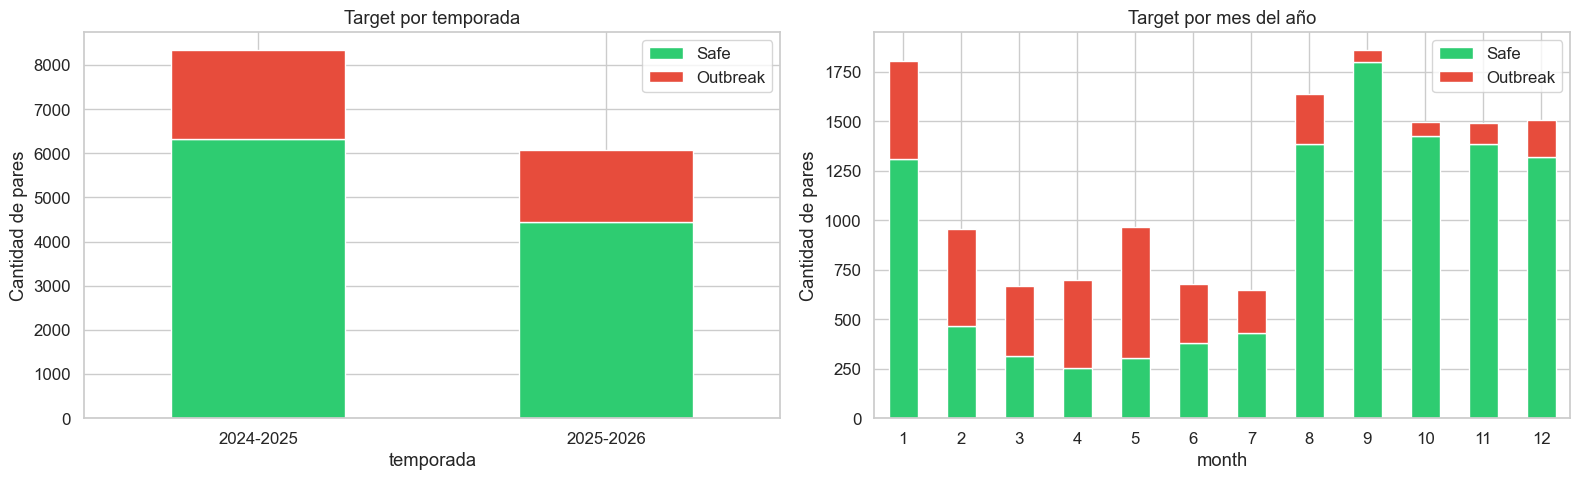

In [5]:
# 3.1 Distribución del target por temporada y mes
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Por temporada
ct = df_pairs.groupby("temporada")["target"].value_counts().unstack(fill_value=0)
ct.plot(kind="bar", stacked=True, color=[TARGET_COLORS[0], TARGET_COLORS[1]], ax=axes[0], edgecolor="white")
axes[0].set_title("Target por temporada")
axes[0].set_ylabel("Cantidad de pares")
axes[0].legend(["Safe", "Outbreak"], loc="upper right")
axes[0].tick_params(axis='x', rotation=0)

# Por mes
ct2 = df_pairs.groupby("month")["target"].value_counts().unstack(fill_value=0)
ct2.plot(kind="bar", stacked=True, color=[TARGET_COLORS[0], TARGET_COLORS[1]], ax=axes[1], edgecolor="white")
axes[1].set_title("Target por mes del año")
axes[1].set_ylabel("Cantidad de pares")
axes[1].legend(["Safe", "Outbreak"], loc="upper right")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

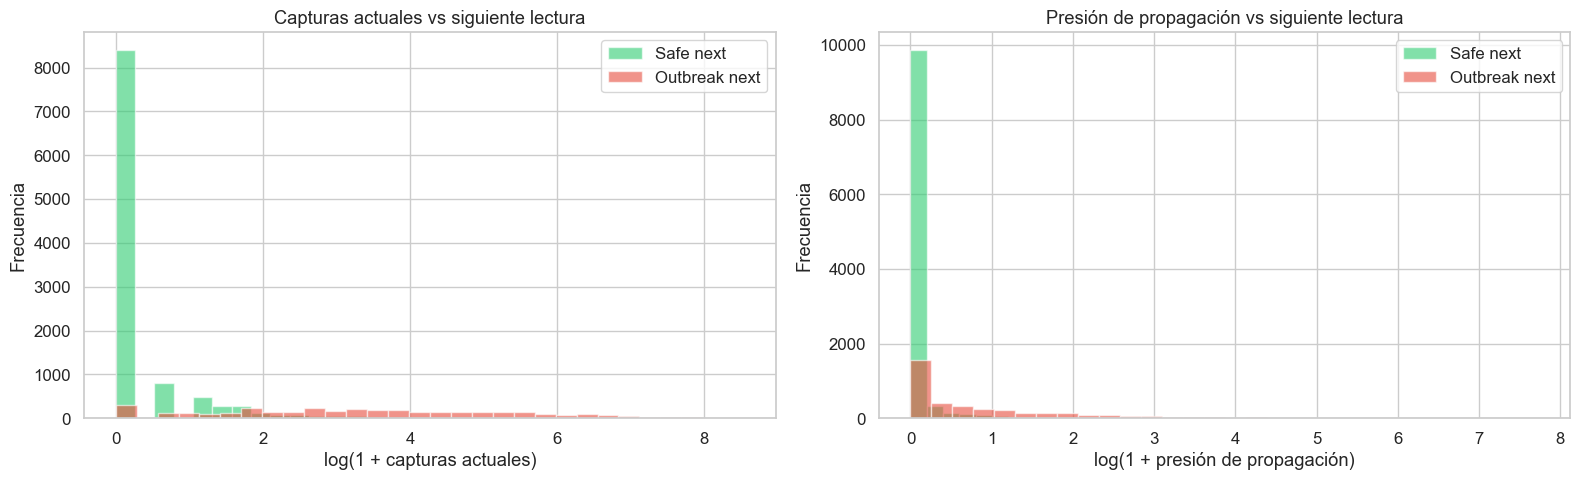

In [6]:
# 3.2 Capturas actuales vs outbreak en siguiente lectura
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for t, color, label in [(0, TARGET_COLORS[0], "Safe next"), (1, TARGET_COLORS[1], "Outbreak next")]:
    mask = df_pairs["target"] == t
    axes[0].hist(np.log1p(df_pairs.loc[mask, "capturas_actual"]), bins=30,
                 alpha=0.6, color=color, label=label, edgecolor="white")
axes[0].set_xlabel("log(1 + capturas actuales)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Capturas actuales vs siguiente lectura")
axes[0].legend()

# Propagation pressure
for t, color, label in [(0, TARGET_COLORS[0], "Safe next"), (1, TARGET_COLORS[1], "Outbreak next")]:
    mask = df_pairs["target"] == t
    axes[1].hist(np.log1p(df_pairs.loc[mask, "propagation_pressure"]), bins=30,
                 alpha=0.6, color=color, label=label, edgecolor="white")
axes[1].set_xlabel("log(1 + presión de propagación)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Presión de propagación vs siguiente lectura")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Entrenamiento del modelo XGBoost

In [7]:
# 4.1 Split temporal
# Garantizamos 0 NaN: historial→0, espacial→0, clima→nearest/API/mediana
df_model = df_pairs.reset_index(drop=True)
X = df_model[feature_cols]
y = df_model["target"]

n_nan = X.isna().sum().sum()
print(f"NaN totales en features: {n_nan}")
assert n_nan == 0, f"¡Hay {n_nan} NaN! Revisar pipeline de features."

train_mask = df_model["temporada"] == "2024-2025"
test_mask = df_model["temporada"] == "2025-2026"

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Train (2024-2025): {len(X_train)} ({y_train.sum()} outbreak, {(y_train==0).sum()} safe)")
print(f"Test  (2025-2026): {len(X_test)} ({y_test.sum()} outbreak, {(y_test==0).sum()} safe)")
print(f"\nBalance train: {y_train.mean():.1%} outbreak")
print(f"Balance test:  {y_test.mean():.1%} outbreak")

NaN totales en features: 0
Train (2024-2025): 8333 (1998 outbreak, 6335 safe)
Test  (2025-2026): 6069 (1623 outbreak, 4446 safe)

Balance train: 24.0% outbreak
Balance test:  26.7% outbreak


In [8]:
# 4.2 Entrenamiento XGBoost
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
scale = n_neg / n_pos if n_pos > 0 else 1.0

model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=1.0,
    min_child_weight=5,
    scale_pos_weight=scale,
    eval_metric="logloss",
    random_state=42,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False,
)
print(f"Modelo entrenado con {len(feature_cols)} features.")
print(f"scale_pos_weight = {scale:.2f}")

Modelo entrenado con 44 features.
scale_pos_weight = 3.17


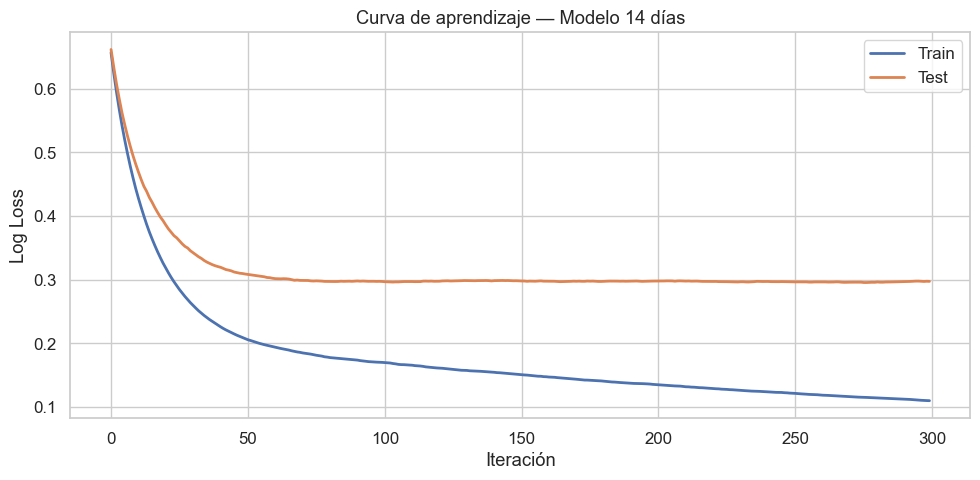

In [9]:
# 4.3 Curva de aprendizaje
results = model.evals_result()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results["validation_0"]["logloss"], label="Train", linewidth=2)
ax.plot(results["validation_1"]["logloss"], label="Test", linewidth=2)
ax.set_xlabel("Iteración")
ax.set_ylabel("Log Loss")
ax.set_title("Curva de aprendizaje — Modelo 14 días")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Evaluación del modelo

In [10]:
# 5.1 Métricas generales
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Buscar mejor threshold por F1
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_test, (y_pred_proba >= t).astype(int), zero_division=0) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Mejor threshold por F1: {best_threshold:.2f} (F1 = {max(f1_scores):.3f})")

DECISION_THRESHOLD = best_threshold
y_pred = (y_pred_proba >= DECISION_THRESHOLD).astype(int)

auc = roc_auc_score(y_test, y_pred_proba)
ap = average_precision_score(y_test, y_pred_proba)

print(f"\n{'='*50}")
print(f"RESULTADOS — Modelo de riesgo a 14 días")
print(f"{'='*50}")
print(f"ROC AUC:           {auc:.3f}")
print(f"Average Precision: {ap:.3f}")
print(f"Threshold:         {DECISION_THRESHOLD:.2f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Safe', 'Outbreak'], zero_division=0)}")

Mejor threshold por F1: 0.65 (F1 = 0.802)

RESULTADOS — Modelo de riesgo a 14 días
ROC AUC:           0.946
Average Precision: 0.868
Threshold:         0.65

              precision    recall  f1-score   support

        Safe       0.93      0.92      0.93      4446
    Outbreak       0.79      0.81      0.80      1623

    accuracy                           0.89      6069
   macro avg       0.86      0.87      0.86      6069
weighted avg       0.89      0.89      0.89      6069



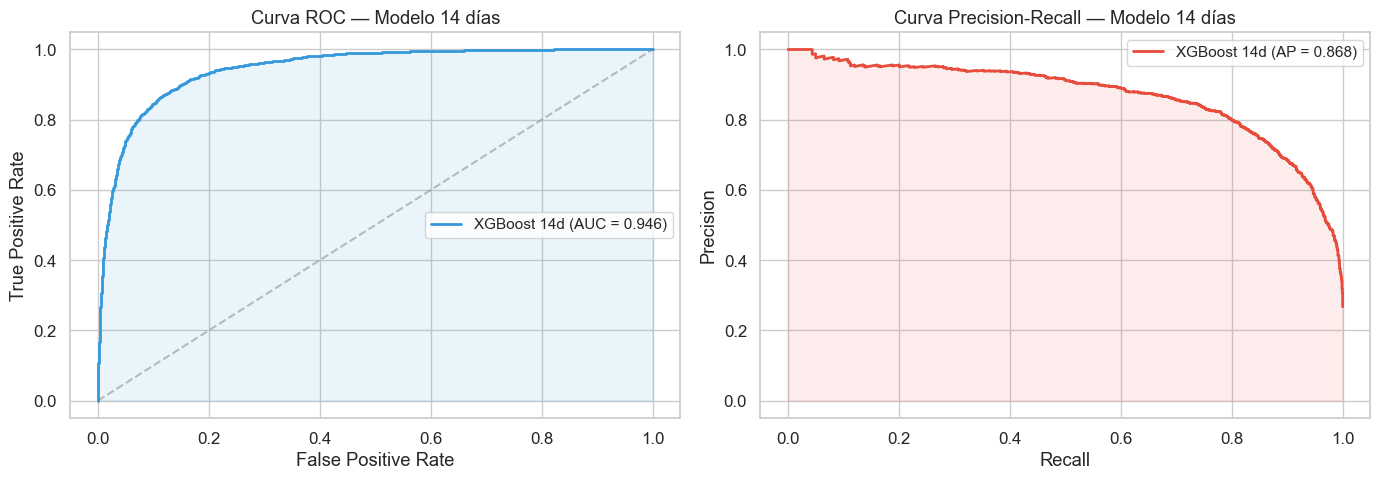

In [11]:
# 5.2 Curva ROC + Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, linewidth=2, color="#3498db", label=f"XGBoost 14d (AUC = {auc:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.5)
axes[0].fill_between(fpr, tpr, alpha=0.1, color="#3498db")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Curva ROC — Modelo 14 días")
axes[0].legend(fontsize=11)

# Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1].plot(rec, prec, linewidth=2, color="#e74c3c", label=f"XGBoost 14d (AP = {ap:.3f})")
axes[1].fill_between(rec, prec, alpha=0.1, color="#e74c3c")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall — Modelo 14 días")
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

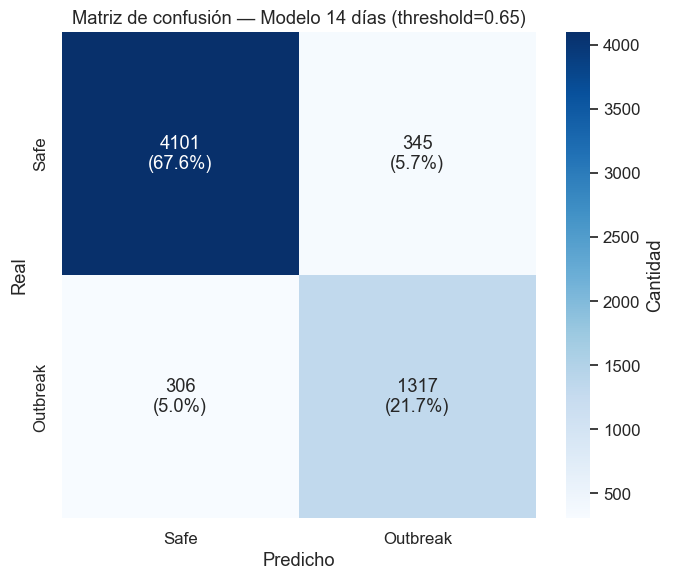

In [12]:
# 5.3 Matriz de confusión
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
labels = np.array([[f"{v}\n({v/cm.sum()*100:.1f}%)" for v in row] for row in cm])
sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", ax=ax,
            xticklabels=["Safe", "Outbreak"], yticklabels=["Safe", "Outbreak"],
            cbar_kws={"label": "Cantidad"})
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_title(f"Matriz de confusión — Modelo 14 días (threshold={DECISION_THRESHOLD:.2f})")
plt.tight_layout()
plt.show()

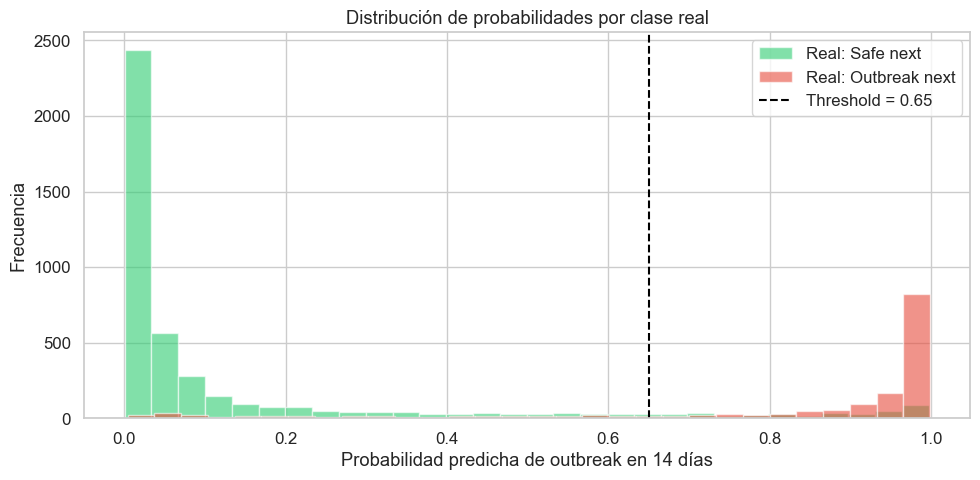

In [13]:
# 5.4 Distribución de probabilidades predichas por clase real
fig, ax = plt.subplots(figsize=(10, 5))
for t, color, label in [(0, TARGET_COLORS[0], "Safe next"), (1, TARGET_COLORS[1], "Outbreak next")]:
    mask = y_test == t
    ax.hist(y_pred_proba[mask], bins=30, alpha=0.6, color=color, label=f"Real: {label}", edgecolor="white")
ax.axvline(x=DECISION_THRESHOLD, color="black", linestyle="--", linewidth=1.5,
           label=f"Threshold = {DECISION_THRESHOLD:.2f}")
ax.set_xlabel("Probabilidad predicha de outbreak en 14 días")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de probabilidades por clase real")
ax.legend()
plt.tight_layout()
plt.show()

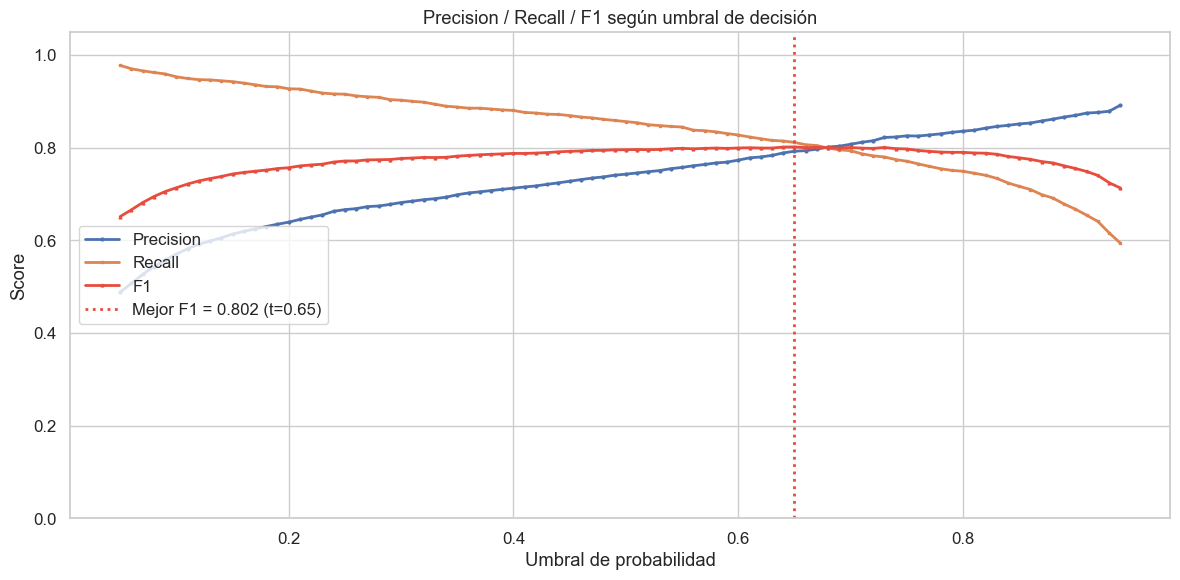

In [14]:
# 5.5 Análisis del threshold de decisión
prob_thresholds = np.arange(0.05, 0.95, 0.01)
prec_list, rec_list, f1_list = [], [], []

for pt in prob_thresholds:
    pred_pt = (y_pred_proba >= pt).astype(int)
    tp = ((pred_pt == 1) & (y_test.values == 1)).sum()
    fp = ((pred_pt == 1) & (y_test.values == 0)).sum()
    fn = ((pred_pt == 0) & (y_test.values == 1)).sum()
    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f = 2 * p * r / (p + r) if (p + r) > 0 else 0
    prec_list.append(p)
    rec_list.append(r)
    f1_list.append(f)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(prob_thresholds, prec_list, "o-", label="Precision", linewidth=2, markersize=2)
ax.plot(prob_thresholds, rec_list, "s-", label="Recall", linewidth=2, markersize=2)
ax.plot(prob_thresholds, f1_list, "^-", label="F1", linewidth=2, color="#e74c3c", markersize=2)

best_idx = np.argmax(f1_list)
ax.axvline(x=prob_thresholds[best_idx], color="#e74c3c", linestyle=":", linewidth=2,
           label=f"Mejor F1 = {f1_list[best_idx]:.3f} (t={prob_thresholds[best_idx]:.2f})")

ax.set_xlabel("Umbral de probabilidad")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 según umbral de decisión")
ax.legend(loc="center left")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 6. Feature Importance

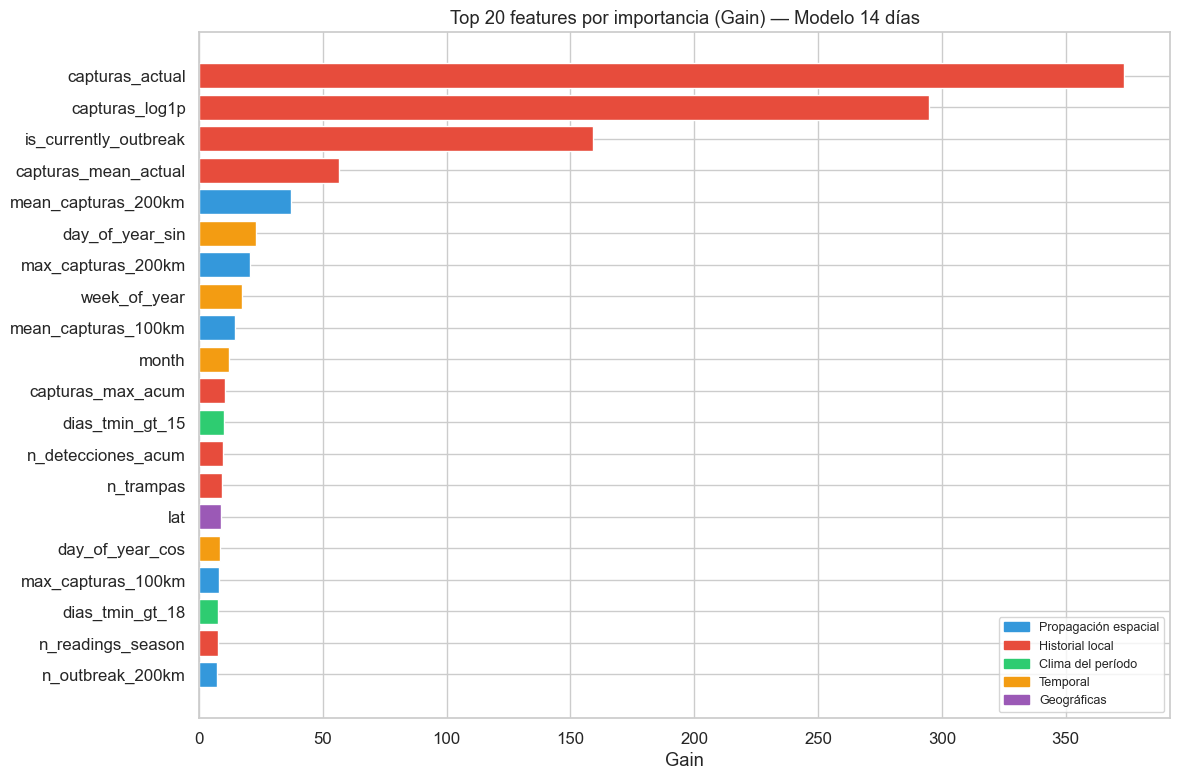

In [15]:
# Colores por categoría
category_colors = {
    "Historial local": "#e74c3c",
    "Propagación espacial": "#3498db",
    "Clima del período": "#2ecc71",
    "Temporal": "#f39c12",
    "Geográficas": "#9b59b6",
}

def get_category(feat):
    for group, cols in feature_groups.items():
        if feat in cols:
            return group
    return "Otro"

# 6.1 Importancia por ganancia (top 20)
gain = model.get_booster().get_score(importance_type="gain")
gain_df = pd.DataFrame({"feature": gain.keys(), "gain": gain.values()})
gain_df = gain_df.sort_values("gain", ascending=True).tail(20)
gain_df["category"] = gain_df["feature"].apply(get_category)

fig, ax = plt.subplots(figsize=(12, 8))
colors = [category_colors.get(c, "gray") for c in gain_df["category"]]
ax.barh(gain_df["feature"], gain_df["gain"], color=colors, edgecolor="white")
ax.set_xlabel("Gain")
ax.set_title("Top 20 features por importancia (Gain) — Modelo 14 días")

from matplotlib.patches import Patch
used_cats = gain_df["category"].unique()
handles = [Patch(color=category_colors[c], label=c) for c in used_cats if c in category_colors]
ax.legend(handles=handles, loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

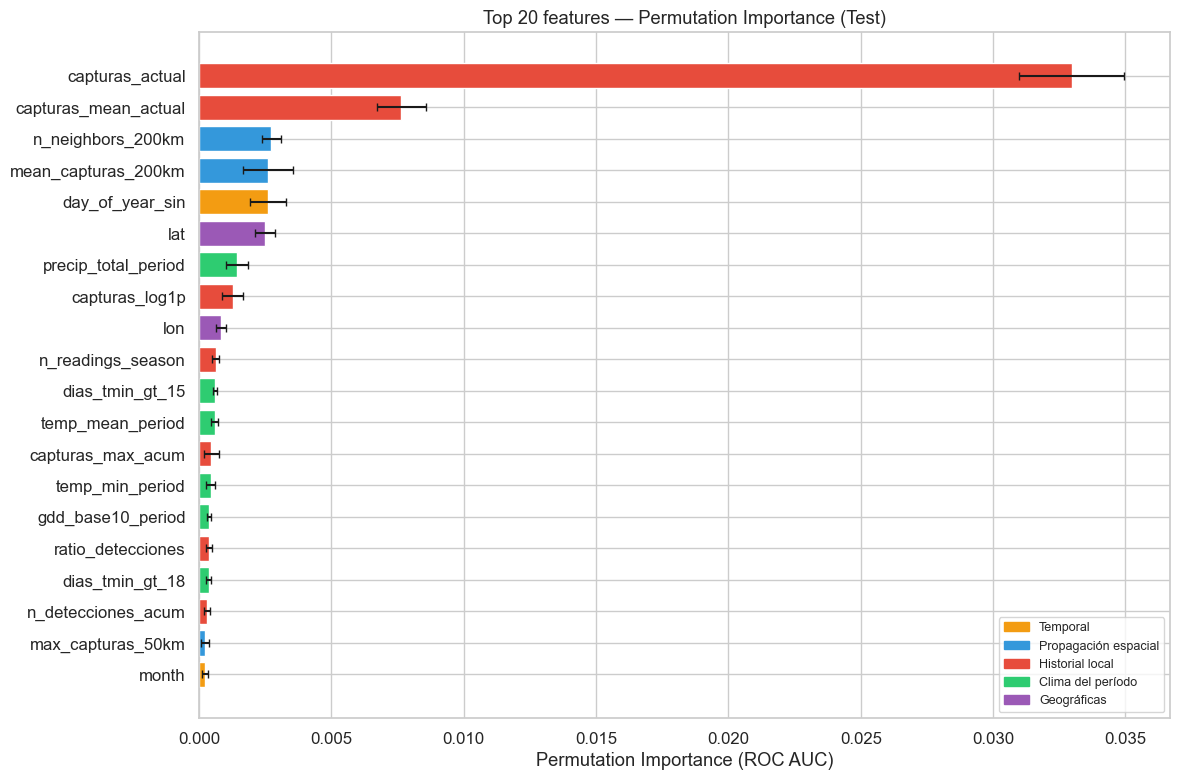

In [16]:
# 6.2 Permutation importance (test set)
perm = permutation_importance(model, X_test, y_test, n_repeats=10,
                               random_state=42, scoring="roc_auc")
perm_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": perm.importances_mean,
    "std": perm.importances_std,
}).sort_values("importance", ascending=True).tail(20)
perm_df["category"] = perm_df["feature"].apply(get_category)

fig, ax = plt.subplots(figsize=(12, 8))
colors = [category_colors.get(c, "gray") for c in perm_df["category"]]
ax.barh(perm_df["feature"], perm_df["importance"], xerr=perm_df["std"],
        color=colors, edgecolor="white", capsize=3)
ax.set_xlabel("Permutation Importance (ROC AUC)")
ax.set_title("Top 20 features — Permutation Importance (Test)")

used_cats = perm_df["category"].unique()
handles = [Patch(color=category_colors[c], label=c) for c in used_cats if c in category_colors]
ax.legend(handles=handles, loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## 7. SHAP — Explicabilidad

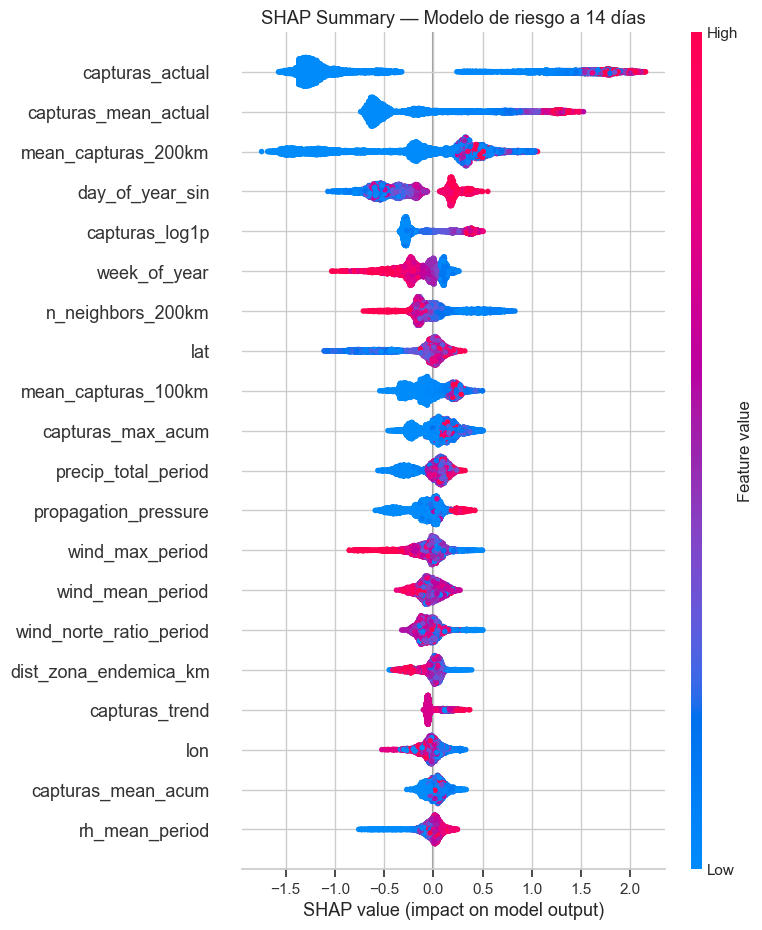

In [17]:
# 7.1 SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot (beeswarm)
plt.figure(figsize=(12, 9))
shap.summary_plot(shap_values, X_test, show=False, max_display=20)
plt.title("SHAP Summary — Modelo de riesgo a 14 días")
plt.tight_layout()
plt.show()

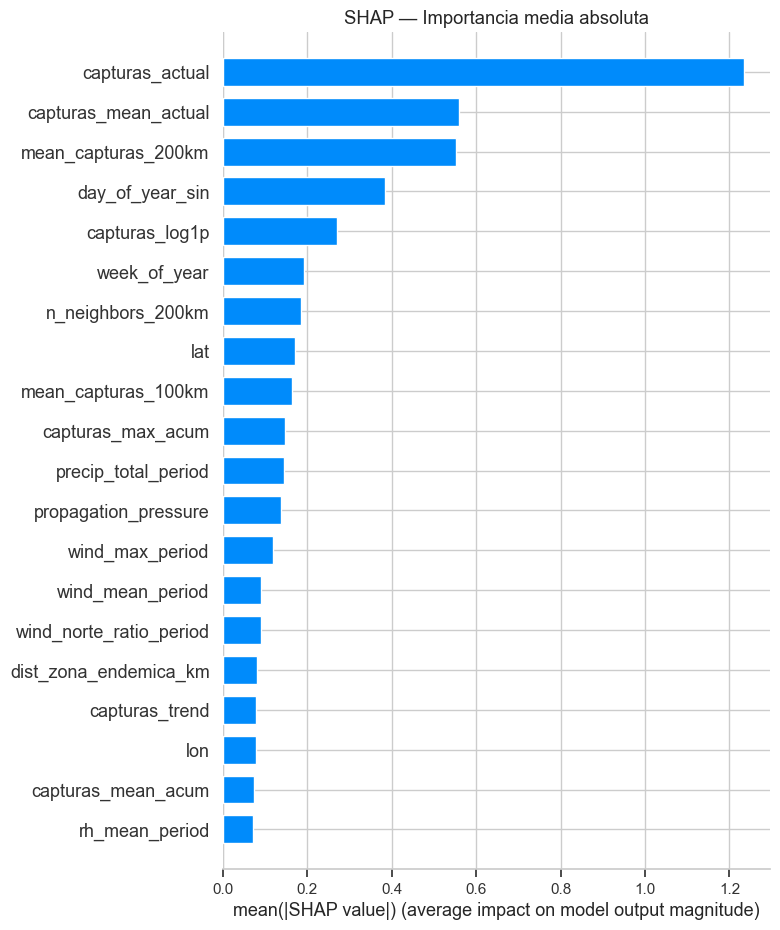

In [18]:
# 7.2 SHAP Bar plot
plt.figure(figsize=(12, 9))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, max_display=20)
plt.title("SHAP — Importancia media absoluta")
plt.tight_layout()
plt.show()

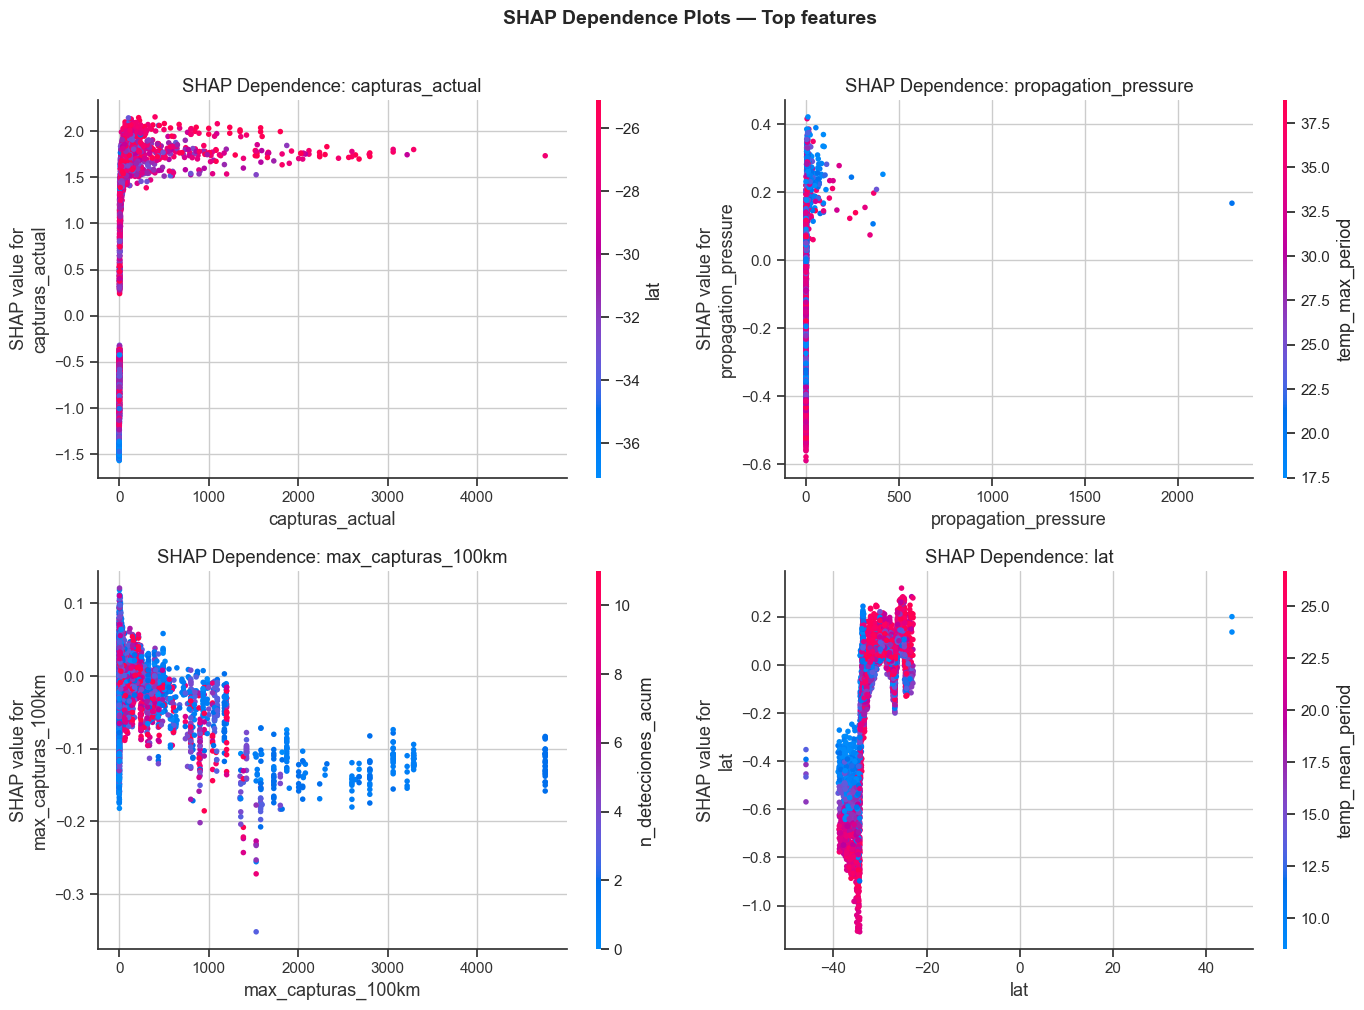

In [19]:
# 7.3 SHAP Dependence plots — top features
top_feats = ["capturas_actual", "propagation_pressure", "max_capturas_100km", "lat"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat in zip(axes.flat, top_feats):
    shap.dependence_plot(feat, shap_values, X_test, ax=ax, show=False)
    ax.set_title(f"SHAP Dependence: {feat}")

plt.suptitle("SHAP Dependence Plots — Top features", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

Ejemplo: probabilidad = 0.999, real = 1
Localidad: el palomar


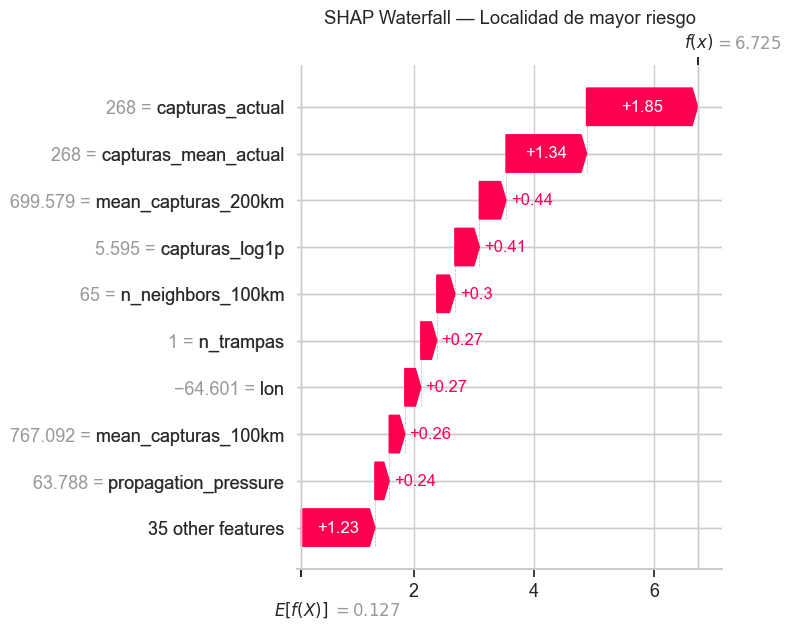

In [20]:
# 7.4 SHAP Waterfall — ejemplo de localidad con alto riesgo
high_risk_idx = y_pred_proba.argmax()
print(f"Ejemplo: probabilidad = {y_pred_proba[high_risk_idx]:.3f}, real = {y_test.iloc[high_risk_idx]}")
print(f"Localidad: {df_model.iloc[X_test.index[high_risk_idx]]['localidad']}")

shap_explanation = shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[high_risk_idx],
    feature_names=feature_cols,
)
plt.figure(figsize=(10, 8))
shap.plots.waterfall(shap_explanation, show=False)
plt.title("SHAP Waterfall — Localidad de mayor riesgo")
plt.tight_layout()
plt.show()

## 8. Análisis por región

In [21]:
# 8.1 Métricas por región (solo test)
test_df = df_model[test_mask].copy()
test_df["pred_proba"] = y_pred_proba
test_df["pred"] = y_pred

REGIONS = ["NOA", "NEA", "CENTRO NORTE", "LITORAL", "CENTRO SUR", "URUGUAY"]
rows = []
for region in REGIONS:
    sub = test_df[test_df["region"] == region]
    if len(sub) < 5:
        continue
    tp = ((sub["pred"] == 1) & (sub["target"] == 1)).sum()
    fp = ((sub["pred"] == 1) & (sub["target"] == 0)).sum()
    fn = ((sub["pred"] == 0) & (sub["target"] == 1)).sum()
    tn = ((sub["pred"] == 0) & (sub["target"] == 0)).sum()
    auc_r = roc_auc_score(sub["target"], sub["pred_proba"]) if sub["target"].nunique() > 1 else None
    rows.append({
        "Región": region, "N": len(sub),
        "Outbreak real": sub["target"].sum(),
        "Outbreak pred": sub["pred"].sum(),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "Precision": tp / (tp + fp) if (tp + fp) > 0 else 0,
        "Recall": tp / (tp + fn) if (tp + fn) > 0 else 0,
        "AUC": auc_r,
    })

region_table = pd.DataFrame(rows)
print("Métricas por región (Test 2025-2026):\n")
display(region_table.round(3))

Métricas por región (Test 2025-2026):



,Región,N,Outbreak real,Outbreak pred,TP,FP,FN,TN,Precision,Recall,AUC
0,NOA,1089,543,500,440,60,103,486,0.880,0.810,0.920
1,NEA,1003,448,452,374,78,74,477,0.827,0.835,0.919
2,CENTRO NORTE,1252,352,375,290,85,62,815,0.773,0.824,0.937
3,LITORAL,552,162,167,123,44,39,346,0.737,0.759,0.905
4,CENTRO SUR,2037,101,161,83,78,18,1858,0.516,0.822,0.973
5,URUGUAY,83,13,7,7,0,6,70,1.000,0.538,0.857


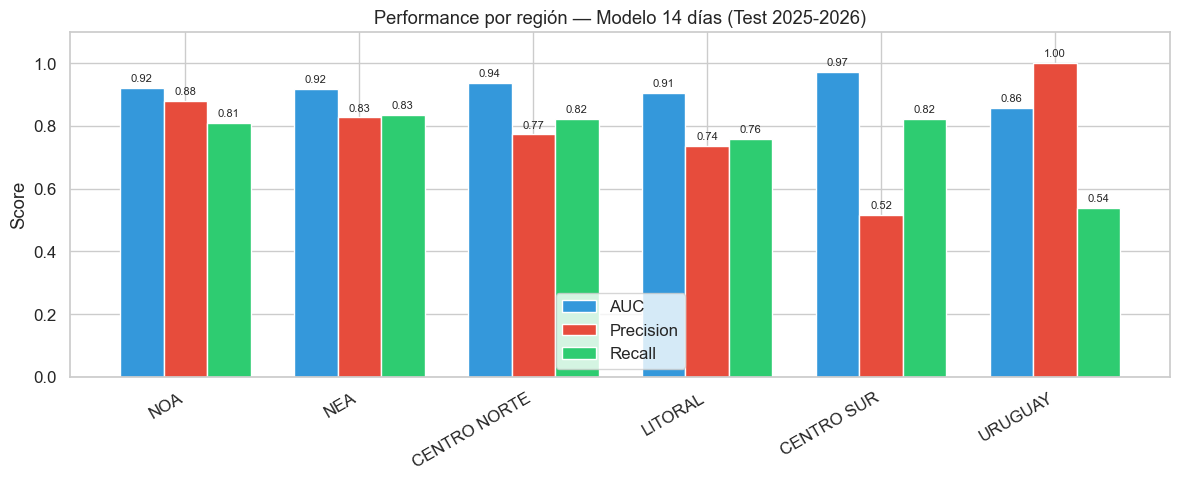

In [22]:
# 8.2 Performance por región (bar chart)
fig, ax = plt.subplots(figsize=(12, 5))
valid_regions = region_table[region_table["AUC"].notna()]
x = np.arange(len(valid_regions))
width = 0.25

bars1 = ax.bar(x - width, valid_regions["AUC"], width, label="AUC", color="#3498db")
bars2 = ax.bar(x, valid_regions["Precision"], width, label="Precision", color="#e74c3c")
bars3 = ax.bar(x + width, valid_regions["Recall"], width, label="Recall", color="#2ecc71")

ax.set_xticks(x)
ax.set_xticklabels(valid_regions["Región"], rotation=30, ha="right")
ax.set_ylabel("Score")
ax.set_title("Performance por región — Modelo 14 días (Test 2025-2026)")
ax.legend()
ax.set_ylim(0, 1.1)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        if bar.get_height() > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f"{bar.get_height():.2f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

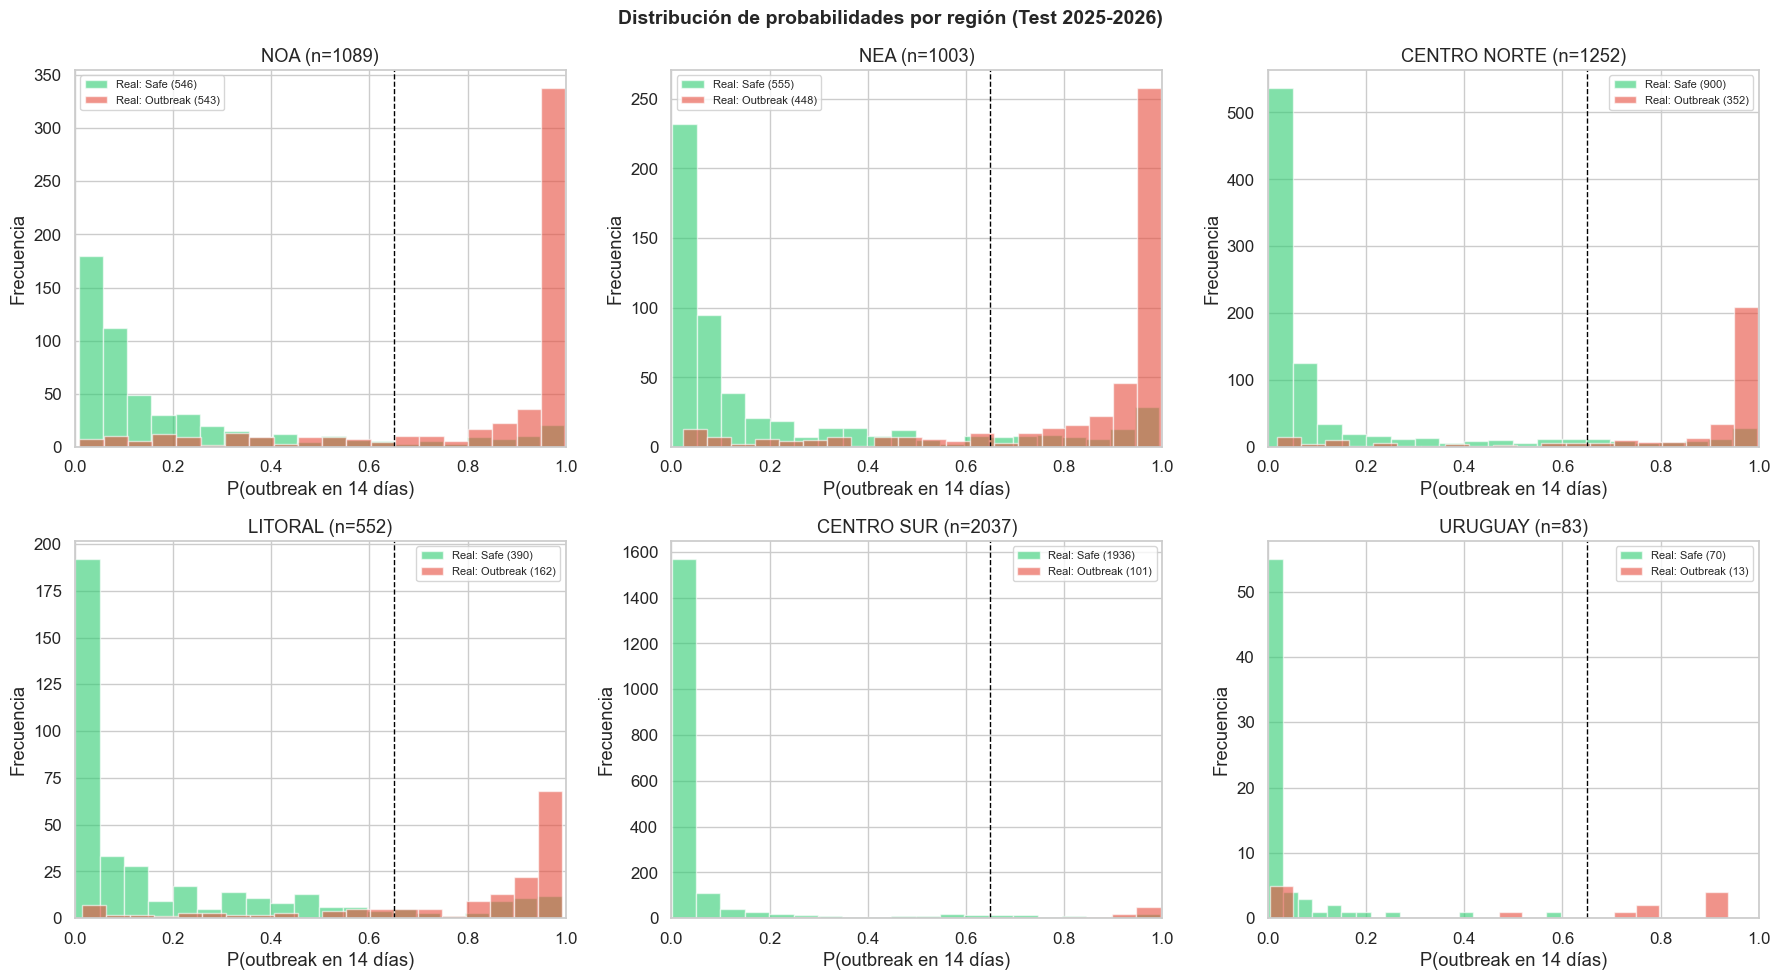

In [23]:
# 8.3 Distribución de probabilidad predicha por región (test)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, region in zip(axes.flat, REGIONS):
    sub = test_df[test_df["region"] == region]
    if len(sub) < 5:
        ax.set_visible(False)
        continue
    for t, color, label in [(0, TARGET_COLORS[0], "Safe"), (1, TARGET_COLORS[1], "Outbreak")]:
        mask = sub["target"] == t
        if mask.sum() > 0:
            ax.hist(sub.loc[mask, "pred_proba"], bins=20, alpha=0.6, color=color,
                    label=f"Real: {label} ({mask.sum()})", edgecolor="white")
    ax.axvline(x=DECISION_THRESHOLD, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{region} (n={len(sub)})")
    ax.set_xlabel("P(outbreak en 14 días)")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)

plt.suptitle("Distribución de probabilidades por región (Test 2025-2026)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Evolución temporal del riesgo

Visualizamos cómo evoluciona la predicción de riesgo a lo largo de la temporada para localidades representativas.

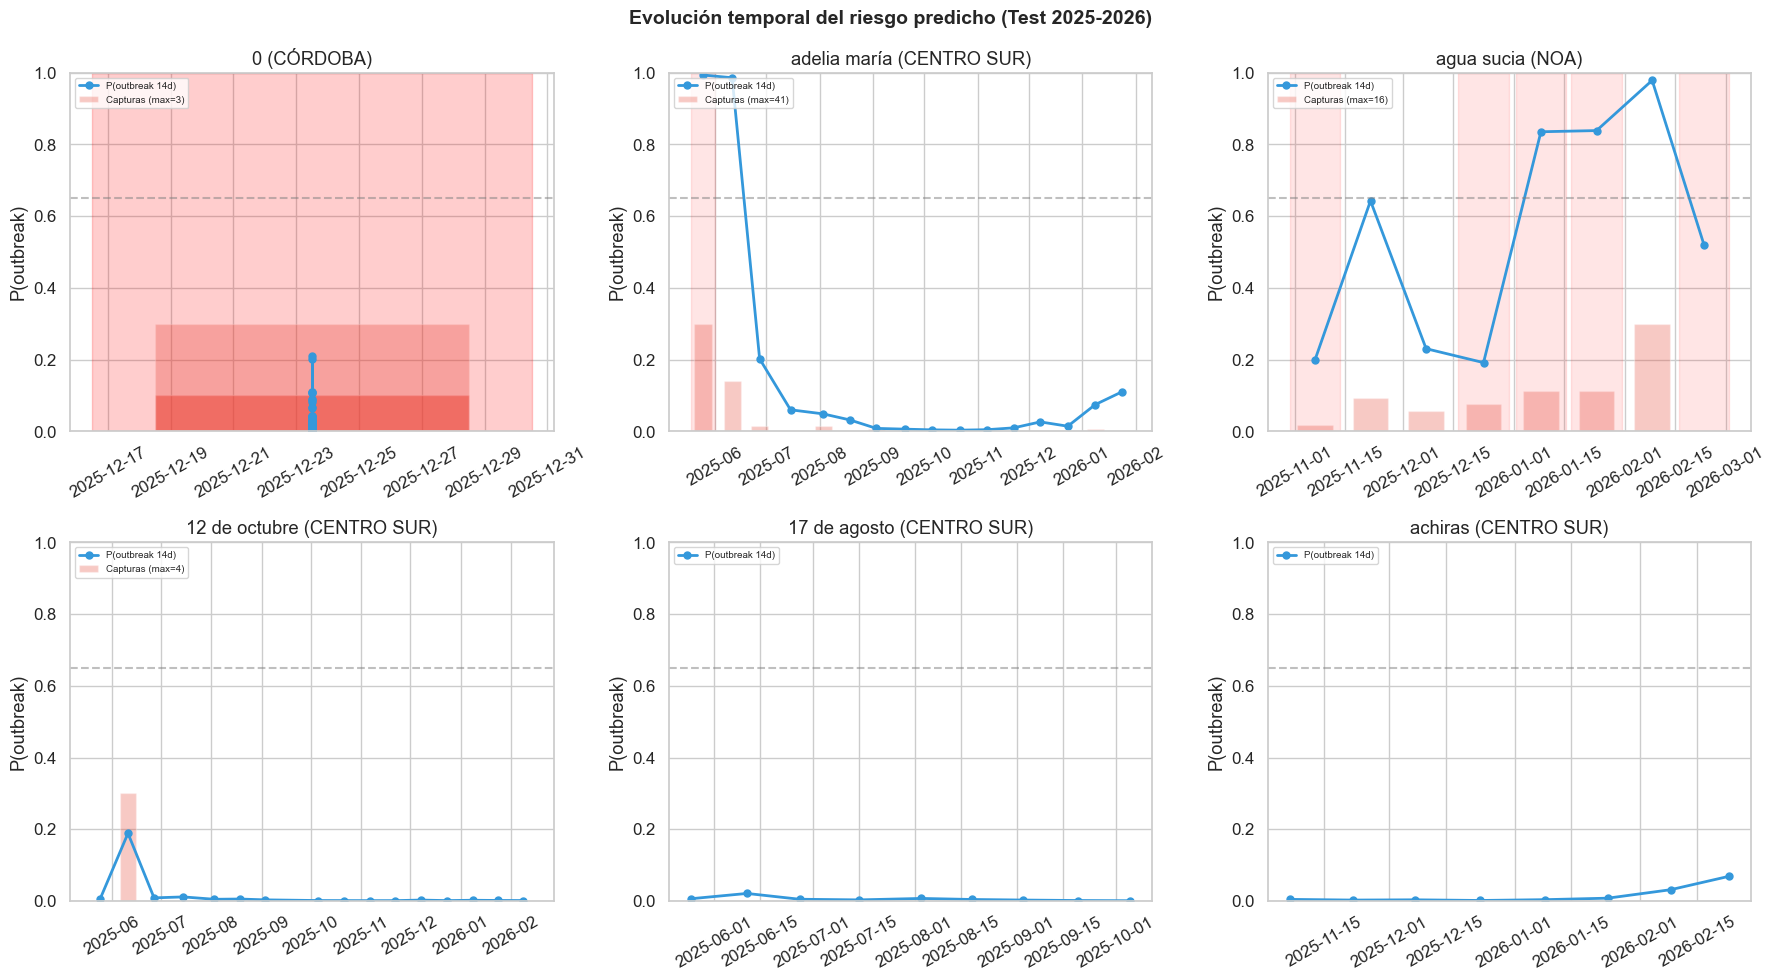

In [24]:
# 9.1 Evolución temporal de riesgo para localidades representativas

# Elegir localidades con al menos 8 lecturas en test
test_counts = test_df.groupby("localidad").size()
top_locs = test_counts[test_counts >= 8].index.tolist()

# Elegir mix: algunas con outbreak, otras sin
outbreak_locs = test_df[test_df["localidad"].isin(top_locs) & (test_df["target"] == 1)]["localidad"].unique()[:3]
safe_locs = test_df[test_df["localidad"].isin(top_locs) & 
                    (~test_df["localidad"].isin(outbreak_locs))]["localidad"].unique()[:3]
selected = list(outbreak_locs) + list(safe_locs)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, loc in zip(axes.flat, selected[:6]):
    sub = test_df[test_df["localidad"] == loc].sort_values("fecha_mid")
    
    # Riesgo predicho
    ax.plot(sub["fecha_mid"], sub["pred_proba"], "o-", color="#3498db",
            linewidth=2, markersize=5, label="P(outbreak 14d)")
    
    # Capturas reales (normalizado)
    max_cap = sub["capturas_actual"].max()
    if max_cap > 0:
        ax.bar(sub["fecha_mid"], sub["capturas_actual"] / max_cap * 0.3,
               width=10, alpha=0.3, color="#e74c3c", label=f"Capturas (max={max_cap:.0f})")
    
    # Threshold
    ax.axhline(y=DECISION_THRESHOLD, color="gray", linestyle="--", alpha=0.5)
    
    # Target real
    outbreak_dates = sub[sub["target"] == 1]["fecha_mid"]
    for d in outbreak_dates:
        ax.axvspan(d - timedelta(days=7), d + timedelta(days=7), alpha=0.1, color="red")
    
    region = sub["region"].iloc[0]
    ax.set_title(f"{loc} ({region})")
    ax.set_ylabel("P(outbreak)")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7, loc="upper left")
    ax.tick_params(axis='x', rotation=30)

plt.suptitle("Evolución temporal del riesgo predicho (Test 2025-2026)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 10. Mapa de riesgo en un momento dado

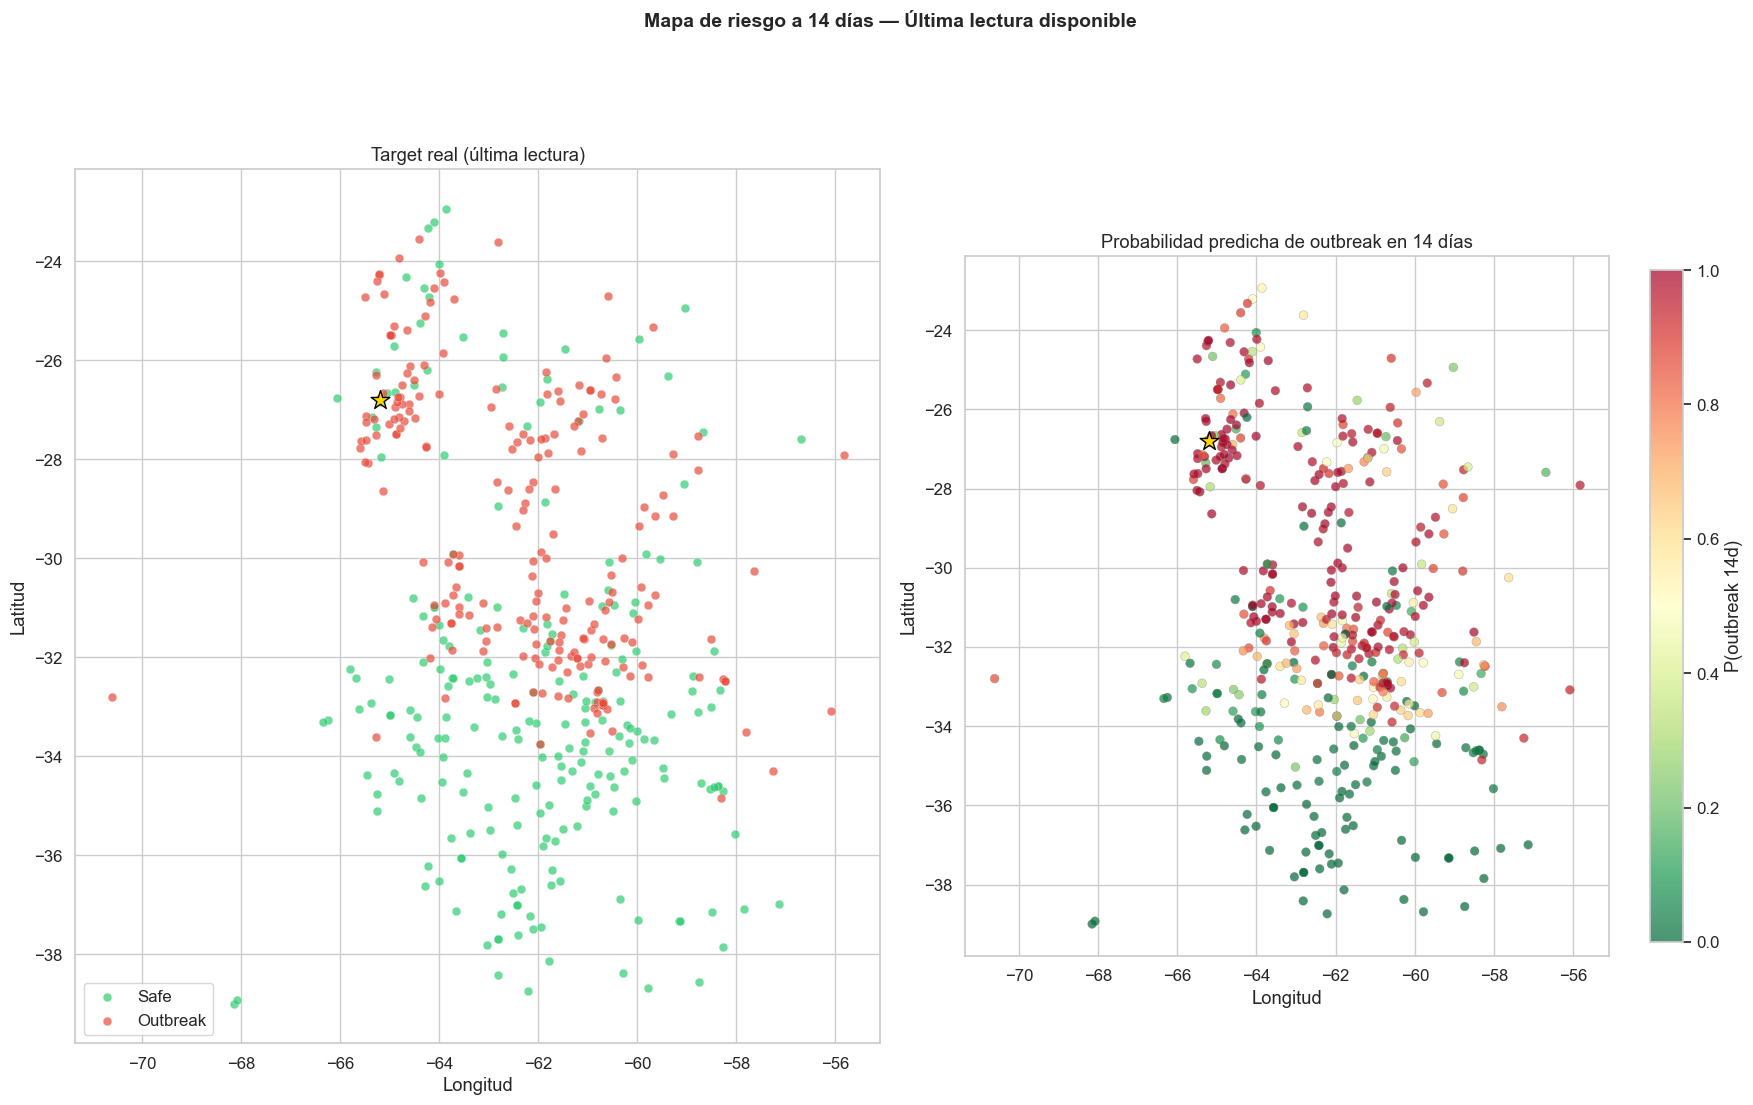

In [25]:
# 10.1 Mapa de riesgo para la última lectura disponible de cada localidad

# Tomar la última predicción por localidad en test
last_pred = test_df.sort_values("fecha_mid").groupby("localidad").last().reset_index()
last_pred = last_pred[(last_pred["lat"] > -45) & (last_pred["lat"] < -20) &
                       (last_pred["lon"] > -75) & (last_pred["lon"] < -53)]

fig, axes = plt.subplots(1, 2, figsize=(18, 12))

# Real
for t in [0, 1]:
    mask = last_pred["target"] == t
    color = TARGET_COLORS[t]
    label = "Safe" if t == 0 else "Outbreak"
    axes[0].scatter(last_pred.loc[mask, "lon"], last_pred.loc[mask, "lat"],
                     c=color, label=label, s=40, alpha=0.7, edgecolors="white", linewidth=0.3)
axes[0].scatter(ENDEMIC_LON, ENDEMIC_LAT, c="gold", marker="*", s=200, zorder=5, edgecolors="black")
axes[0].set_title("Target real (última lectura)")
axes[0].legend(loc="lower left")
axes[0].set_aspect("equal")

# Risk predicho
sc = axes[1].scatter(
    last_pred["lon"], last_pred["lat"],
    c=last_pred["pred_proba"], cmap="RdYlGn_r", s=40,
    alpha=0.7, edgecolors="gray", linewidth=0.3, vmin=0, vmax=1,
)
axes[1].scatter(ENDEMIC_LON, ENDEMIC_LAT, c="gold", marker="*", s=200, zorder=5, edgecolors="black")
axes[1].set_title("Probabilidad predicha de outbreak en 14 días")
axes[1].set_aspect("equal")
plt.colorbar(sc, ax=axes[1], shrink=0.6, label="P(outbreak 14d)")

for ax in axes:
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")

plt.suptitle("Mapa de riesgo a 14 días — Última lectura disponible", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 11. Exportar modelo y metadata para producción

Guardamos el modelo entrenado y la metadata necesaria para usarlo en la API/backend durante la temporada.

In [26]:
# 11.1 Guardar modelo y config
import json

# Guardar modelo
model.save_model("output/model_14d.json")

# Metadata
model_meta = {
    "model_type": "xgboost_14d_risk",
    "description": "Predicción de riesgo de outbreak de Dalbulus maidis en los próximos 14 días",
    "target": f"capturas_max >= {CAPTURE_THRESHOLD} en siguiente lectura (~14 días)",
    "decision_threshold": float(DECISION_THRESHOLD),
    "feature_cols": feature_cols,
    "feature_groups": {k: v for k, v in feature_groups.items()},
    "n_features": len(feature_cols),
    "train_season": "2024-2025",
    "test_season": "2025-2026",
    "train_samples": int(len(X_train)),
    "test_samples": int(len(X_test)),
    "metrics": {
        "roc_auc": float(auc),
        "avg_precision": float(ap),
        "best_f1": float(max(f1_scores)),
        "best_threshold": float(best_threshold),
    },
    "capture_threshold": CAPTURE_THRESHOLD,
    "generated_at": datetime.now().isoformat(),
}

with open("output/model_14d_metadata.json", "w") as f:
    json.dump(model_meta, f, indent=2, ensure_ascii=False)

# Guardar dataset temporal para uso posterior
df_model.to_csv("output/dataset_14d.csv", index=False)

print("Archivos guardados:")
print("  output/model_14d.json          — Modelo XGBoost")
print("  output/model_14d_metadata.json  — Metadata y features")
print("  output/dataset_14d.csv          — Dataset temporal completo")
print(f"\nMétricas finales:")
print(f"  ROC AUC:    {auc:.3f}")
print(f"  Avg Prec:   {ap:.3f}")
print(f"  Best F1:    {max(f1_scores):.3f} (threshold={best_threshold:.2f})")

Archivos guardados:
  output/model_14d.json          — Modelo XGBoost
  output/model_14d_metadata.json  — Metadata y features
  output/dataset_14d.csv          — Dataset temporal completo

Métricas finales:
  ROC AUC:    0.946
  Avg Prec:   0.868
  Best F1:    0.802 (threshold=0.65)


## 12. Red Neuronal (MLP) — Baseline para modelo híbrido

Entrenamos la **misma arquitectura MLP** que usa la rama tabular del modelo híbrido CNN+Tabular (notebook 04), pero **sin la rama CNN**. Esto sirve como baseline para medir cuánto aporta el NDVI satelital.

### Arquitectura (idéntica a la rama tabular del híbrido)

```
Input (N_features) → Linear(128) → BN → ReLU → Drop(0.3)
                   → Linear(64)  → BN → ReLU → Drop(0.3)
                   → Linear(32)  [embedding]
                   → Linear(32)  → ReLU → Drop(0.2)
                   → Linear(1)   → Sigmoid → P(outbreak)
```

- **Focal Loss** (α=0.6, γ=2.0) para desbalance
- **AdamW** + cosine annealing
- **Early stopping** sobre AUC del test set

In [ ]:
# 12.1 Definición del modelo MLP + Dataset + Training loop

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available()
    #else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Device: {DEVICE}', flush=True)


class FocalLoss(nn.Module):
    """Focal Loss para clasificación desbalanceada."""
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        probs = torch.sigmoid(inputs)
        pt = torch.where(targets == 1, probs, 1 - probs)
        alpha_t = torch.where(targets == 1, self.alpha, 1 - self.alpha)
        focal_weight = alpha_t * (1 - pt) ** self.gamma
        return (focal_weight * bce).mean()


class TabularMLPModel(nn.Module):
    """
    MLP idéntico a la rama tabular del modelo híbrido (notebook 04):
    TabularBranch → embedding(32d) → FusionHead → P(outbreak)
    """
    def __init__(self, n_features, embedding_dim=32):
        super().__init__()
        # Rama tabular (idéntica a TabularBranch del híbrido)
        self.tabular_branch = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, embedding_dim),
        )
        # Fusion head (idéntico al híbrido pero solo con tab_embed)
        self.fusion = nn.Sequential(
            nn.Linear(embedding_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        emb = self.tabular_branch(x)
        return self.fusion(emb).squeeze(1)

    def get_embedding(self, x):
        return self.tabular_branch(x)


class TabularDataset(Dataset):
    def __init__(self, features, targets, scaler=None):
        if scaler is not None:
            features = scaler.transform(features)
        self.X = torch.FloatTensor(features)
        self.y = torch.FloatTensor(targets)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# --- Preparar datos ---
scaler_mlp = StandardScaler()
X_train_scaled = scaler_mlp.fit_transform(X_train.values)
X_test_scaled = scaler_mlp.transform(X_test.values)

train_dataset = TabularDataset(X_train_scaled, y_train.values.astype(np.float32))
test_dataset = TabularDataset(X_test_scaled, y_test.values.astype(np.float32))

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train: {len(train_dataset)} samples, {len(train_loader)} batches', flush=True)
print(f'Test:  {len(test_dataset)} samples, {len(test_loader)} batches', flush=True)

# --- Instanciar modelo ---
mlp_model = TabularMLPModel(n_features=len(feature_cols)).to(DEVICE)
n_params = sum(p.numel() for p in mlp_model.parameters())
print(f'\nMLP Model: {n_params:,} parámetros', flush=True)
print(mlp_model, flush=True)


# --- Training loop ---
def train_epoch_mlp(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_mlp(model, loader):
    model.eval()
    all_probs, all_targets = [], []
    total_loss = 0
    criterion = FocalLoss(alpha=0.6, gamma=2.0)
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        total_loss += loss.item() * len(y_batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)
        all_targets.extend(y_batch.cpu().numpy())
    all_probs = np.array(all_probs)
    all_targets = np.array(all_targets)
    auc_val = roc_auc_score(all_targets, all_probs) if len(np.unique(all_targets)) > 1 else 0.5
    ap_val = average_precision_score(all_targets, all_probs) if len(np.unique(all_targets)) > 1 else 0.0
    return total_loss / len(loader.dataset), auc_val, ap_val, all_probs, all_targets


# --- Entrenar ---
criterion_mlp = FocalLoss(alpha=0.6, gamma=2.0)
optimizer_mlp = optim.AdamW(mlp_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_mlp = optim.lr_scheduler.CosineAnnealingLR(optimizer_mlp, T_max=50, eta_min=1e-5)

N_EPOCHS = 50
PATIENCE = 10
best_auc_mlp = 0
patience_counter = 0
history_mlp = {'train_loss': [], 'test_loss': [], 'test_auc': [], 'test_ap': []}

import time
from IPython.display import display, HTML, clear_output

header = (
    f"<b>Entrenando MLP</b> — {N_EPOCHS} epochs max | patience={PATIENCE} | device={DEVICE}<br>"
    f"<pre>{'Epoch':>6} | {'TrainLoss':>9} | {'TestLoss':>8} | {'AUC':>6} | {'AP':>6} | {'LR':>8} | Pat | Seg</pre>"
    "<pre>" + "-" * 68 + "</pre>"
)
rows = []

t0_total = time.time()
for epoch in range(N_EPOCHS):
    # Aviso inmediato antes del cómputo costoso
    clear_output(wait=True)
    display(HTML(
        header
        + "<pre>" + "\n".join(rows) + "</pre>"
        + f"<i>⏳ Epoch {epoch+1}/{N_EPOCHS} en progreso...</i>"
    ))

    t0 = time.time()
    train_loss = train_epoch_mlp(mlp_model, train_loader, criterion_mlp, optimizer_mlp)
    test_loss, test_auc_e, test_ap_e, _, _ = evaluate_mlp(mlp_model, test_loader)
    scheduler_mlp.step()
    elapsed = time.time() - t0

    history_mlp['train_loss'].append(train_loss)
    history_mlp['test_loss'].append(test_loss)
    history_mlp['test_auc'].append(test_auc_e)
    history_mlp['test_ap'].append(test_ap_e)

    improved = test_auc_e > best_auc_mlp
    if improved:
        best_auc_mlp = test_auc_e
        patience_counter = 0
        torch.save(mlp_model.state_dict(), 'output/mlp_baseline_best.pt')
    else:
        patience_counter += 1

    lr = optimizer_mlp.param_groups[0]['lr']
    marker = ' ◀' if improved else ''
    rows.append(
        f"{epoch+1:>6} | {train_loss:>9.4f} | {test_loss:>8.4f} | "
        f"{test_auc_e:>6.3f} | {test_ap_e:>6.3f} | {lr:>8.1e} | {patience_counter:>2}{marker} | {elapsed:.1f}s"
    )

    if patience_counter >= PATIENCE:
        rows.append(f"\n⛔ Early stopping en epoch {epoch+1} (mejor AUC: {best_auc_mlp:.3f})")
        break

total_time = time.time() - t0_total
clear_output(wait=True)
display(HTML(
    header
    + "<pre>" + "\n".join(rows) + "</pre>"
    + f"<br><b>✅ Entrenamiento terminado en {total_time:.1f}s | Mejor AUC = {best_auc_mlp:.3f}</b>"
))

# Cargar mejor modelo
mlp_model.load_state_dict(
    torch.load('output/mlp_baseline_best.pt', map_location=DEVICE, weights_only=True)
)
print(f'Mejor MLP cargado (AUC = {best_auc_mlp:.3f})', flush=True)

Device: cpu


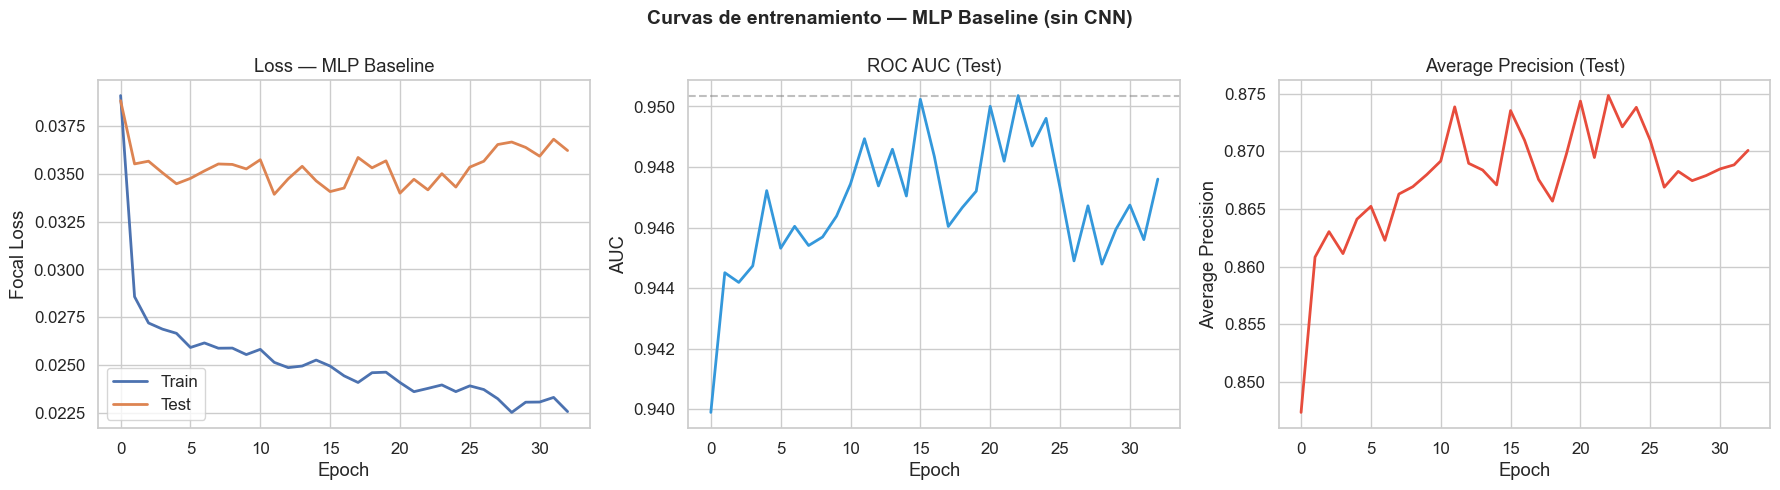

In [ ]:
# 12.2 Curvas de entrenamiento MLP

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_mlp['train_loss'], label='Train', linewidth=2)
axes[0].plot(history_mlp['test_loss'], label='Test', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Focal Loss')
axes[0].set_title('Loss — MLP Baseline')
axes[0].legend()

axes[1].plot(history_mlp['test_auc'], label='AUC', linewidth=2, color='#3498db')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].set_title('ROC AUC (Test)')
axes[1].axhline(best_auc_mlp, linestyle='--', color='gray', alpha=0.5)

axes[2].plot(history_mlp['test_ap'], label='AP', linewidth=2, color='#e74c3c')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Average Precision')
axes[2].set_title('Average Precision (Test)')

plt.suptitle('Curvas de entrenamiento — MLP Baseline (sin CNN)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

RESULTADOS — MLP Baseline (sin CNN)
ROC AUC:           0.950
Average Precision: 0.875
Best F1:           0.807 (threshold=0.46)

              precision    recall  f1-score   support

        Safe       0.94      0.90      0.92      4446
    Outbreak       0.77      0.85      0.81      1623

    accuracy                           0.89      6069
   macro avg       0.85      0.88      0.87      6069
weighted avg       0.90      0.89      0.89      6069


COMPARACIÓN: XGBoost vs MLP Baseline


,Modelo,ROC AUC,Avg Precision,Best F1,Best Threshold
0,XGBoost,0.9463,0.8679,0.8018,0.65
1,MLP Baseline (rama tabular sin CNN),0.9504,0.8748,0.8070,0.46


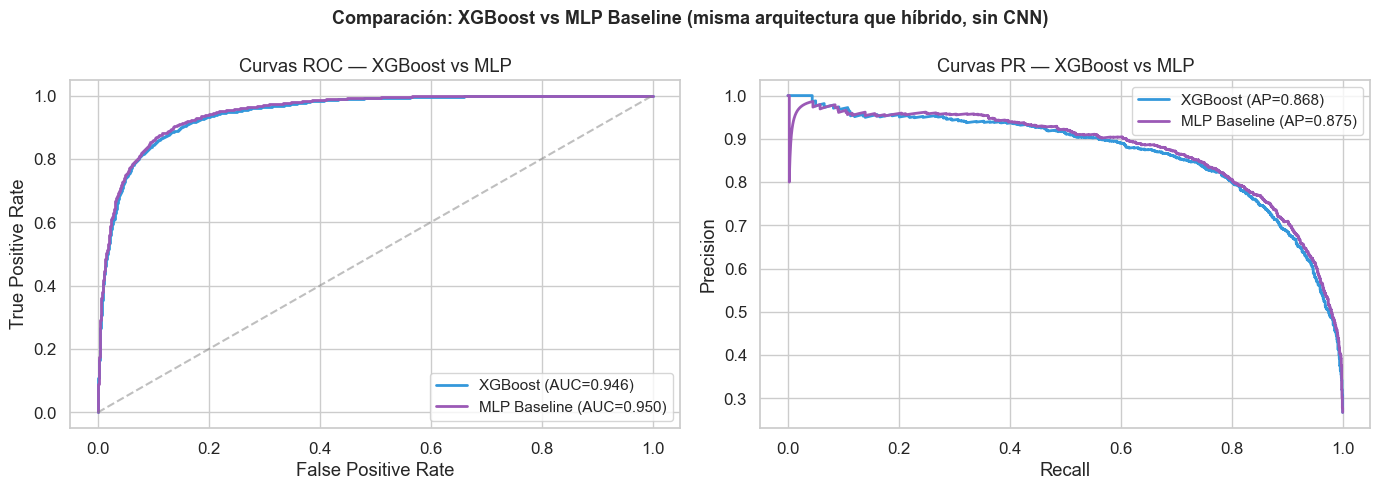

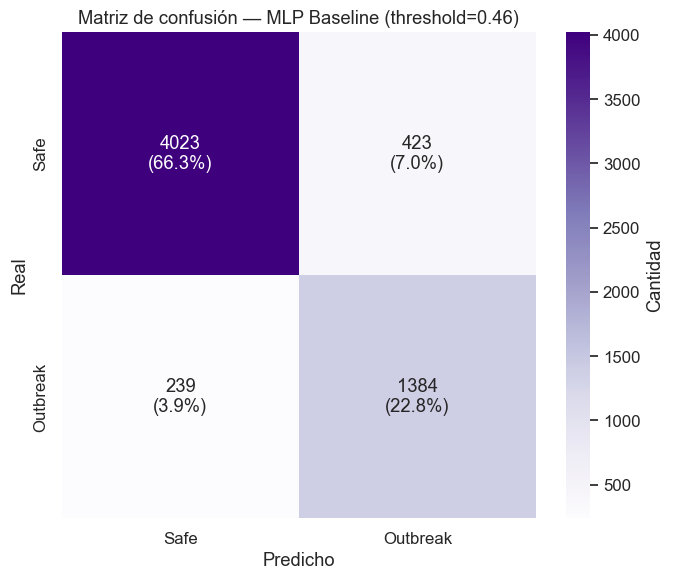

In [ ]:
# 12.3 Evaluación MLP + Comparación con XGBoost

# Evaluar MLP
_, mlp_auc, mlp_ap, y_pred_proba_mlp, y_test_mlp = evaluate_mlp(mlp_model, test_loader)

# Mejor threshold por F1
thresholds_mlp = np.arange(0.1, 0.9, 0.01)
f1_scores_mlp = [
    f1_score(y_test_mlp, (y_pred_proba_mlp >= t).astype(int), zero_division=0)
    for t in thresholds_mlp
]
best_threshold_mlp = thresholds_mlp[np.argmax(f1_scores_mlp)]
y_pred_mlp = (y_pred_proba_mlp >= best_threshold_mlp).astype(int)

print(f"{'='*55}")
print(f"RESULTADOS — MLP Baseline (sin CNN)")
print(f"{'='*55}")
print(f"ROC AUC:           {mlp_auc:.3f}")
print(f"Average Precision: {mlp_ap:.3f}")
print(f"Best F1:           {max(f1_scores_mlp):.3f} (threshold={best_threshold_mlp:.2f})")
print(f"\n{classification_report(y_test_mlp, y_pred_mlp, target_names=['Safe', 'Outbreak'], zero_division=0)}")

# --- Comparación XGBoost vs MLP ---
print(f"\n{'='*55}")
print(f"COMPARACIÓN: XGBoost vs MLP Baseline")
print(f"{'='*55}")
comp_df = pd.DataFrame({
    'Modelo': ['XGBoost', 'MLP Baseline (rama tabular sin CNN)'],
    'ROC AUC': [auc, mlp_auc],
    'Avg Precision': [ap, mlp_ap],
    'Best F1': [max(f1_scores), max(f1_scores_mlp)],
    'Best Threshold': [best_threshold, best_threshold_mlp],
})
display(comp_df.round(4))

# --- Curvas ROC + PR comparativas ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test_mlp, y_pred_proba_mlp)

axes[0].plot(fpr_xgb, tpr_xgb, linewidth=2, color='#3498db',
             label=f'XGBoost (AUC={auc:.3f})')
axes[0].plot(fpr_mlp, tpr_mlp, linewidth=2, color='#9b59b6',
             label=f'MLP Baseline (AUC={mlp_auc:.3f})')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curvas ROC — XGBoost vs MLP')
axes[0].legend(fontsize=11)

# PR
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_pred_proba)
prec_mlp, rec_mlp, _ = precision_recall_curve(y_test_mlp, y_pred_proba_mlp)

axes[1].plot(rec_xgb, prec_xgb, linewidth=2, color='#3498db',
             label=f'XGBoost (AP={ap:.3f})')
axes[1].plot(rec_mlp, prec_mlp, linewidth=2, color='#9b59b6',
             label=f'MLP Baseline (AP={mlp_ap:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curvas PR — XGBoost vs MLP')
axes[1].legend(fontsize=11)

plt.suptitle('Comparación: XGBoost vs MLP Baseline (misma arquitectura que híbrido, sin CNN)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Confusion matrix MLP ---
fig, ax = plt.subplots(figsize=(7, 6))
cm_mlp = confusion_matrix(y_test_mlp, y_pred_mlp)
labels_cm = np.array([[f"{v}\n({v/cm_mlp.sum()*100:.1f}%)" for v in row] for row in cm_mlp])
sns.heatmap(cm_mlp, annot=labels_cm, fmt="", cmap="Purples", ax=ax,
            xticklabels=["Safe", "Outbreak"], yticklabels=["Safe", "Outbreak"],
            cbar_kws={"label": "Cantidad"})
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_title(f"Matriz de confusión — MLP Baseline (threshold={best_threshold_mlp:.2f})")
plt.tight_layout()
plt.show()

In [ ]:
# 12.4 Exportar modelo MLP (solo pesos — evita cuelgues al serializar dicts grandes)


Path("output").mkdir(exist_ok=True)
mlp_path = Path("output/mlp_baseline_14d.pt")
torch.save(mlp_model.state_dict(), mlp_path)
print(f"Guardado: {mlp_path} ({mlp_path.stat().st_size / 1024:.1f} KB)")

AttributeError: 'TabularDataset' object has no attribute 'scaler'